### Cell 1 — Load datasets + label mapping + class distribution plots

In this cell we set up the **basic dataset inspection** workflow:

* **Config + label encoding**
  We define `LABEL2ID` / `ID2LABEL` and store `LEGIT_ID=3` so we can consistently interpret `Target` across the notebook.

* **Dataset loader**
  `load_dataset()` loads a CSV from `Dataset/Preprocessed_Data/`, forces `Target` to numeric, and prints the shape (quick sanity check).

* **Two distribution plots**

  * **Multiclass bar chart** (`plot_multiclass`): counts of each label (`bruteforce`, `dos`, `flood`, `legitimate`, `malformed`, `slowite`).
    This shows **class imbalance** and whether some attacks are rare.
  * **Binary bar chart** (`plot_binary_legitimate_vs_attack`): collapses everything non-legitimate into `attack`.
    This shows whether a binary detector would be biased toward the majority class.

* **Run on both processed datasets**
  We run the same inspection on:

  * `MQTTEEB-D_dataset_All_Processed.csv` (main processed dataset)
  * `MQTTEEB-D_dataset_Processed_SMOTE.csv` (SMOTE-balanced variant)

The output gives us the **baseline imbalance** and whether SMOTE meaningfully changed the class distribution.

MQTTEEB-D_dataset_All_Processed.csv: shape=(222813, 13)


,timestamp,tcp_flags,tcp_time_delta,tcp_len,mqtt_conack_flags,mqtt_conflag_cleansess,mqtt_conflags,mqtt_dupflag,mqtt_hdrflags,mqtt_kalive,mqtt_msg,mqtt_qos,Target
0,2024-09-09 03:17:53.839303017,24,1.725852e+09,617,0,0.0,0,0.0,53,0,37372,2.0,3
1,2024-09-09 03:18:04.324335098,24,1.725852e+09,609,0,0.0,0,0.0,53,0,37373,2.0,3
2,2024-09-09 03:18:14.806340933,24,1.725852e+09,614,0,0.0,0,0.0,53,0,37374,2.0,3
3,2024-09-09 03:18:25.294879913,24,1.725852e+09,615,0,0.0,0,0.0,53,0,37375,2.0,3
4,2024-09-09 03:18:35.780611992,24,1.725852e+09,615,0,0.0,0,0.0,53,0,37376,2.0,3


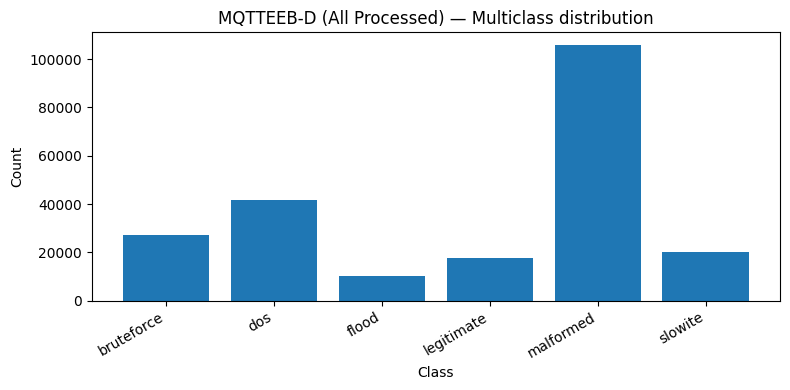

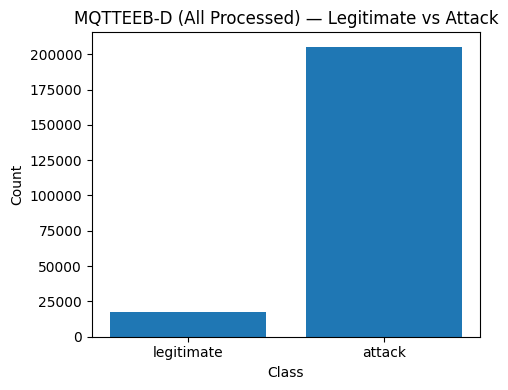

Target
0     27377
1     41802
2     10213
3     17557
4    105774
5     20090
Name: count, dtype: int64

Target
legitimate     17557
attack        205256
Name: count, dtype: int64

MQTTEEB-D_dataset_Processed_SMOTE.csv: shape=(634644, 13)


,timestamp,tcp_flags,tcp_time_delta,tcp_len,mqtt_conack_flags,mqtt_conflag_cleansess,mqtt_conflags,mqtt_dupflag,mqtt_hdrflags,mqtt_kalive,mqtt_msg,mqtt_qos,Target
0,2024-09-09 03:17:53.839302912,24,1.725852e+09,617,0,0.0,0,0.0,53,0,37372,2.0,3
1,2024-09-09 03:18:04.324335104,24,1.725852e+09,609,0,0.0,0,0.0,53,0,37373,2.0,3
2,2024-09-09 03:18:14.806340864,24,1.725852e+09,614,0,0.0,0,0.0,53,0,37374,2.0,3
3,2024-09-09 03:18:25.294880000,24,1.725852e+09,615,0,0.0,0,0.0,53,0,37375,2.0,3
4,2024-09-09 03:18:35.780612096,24,1.725852e+09,615,0,0.0,0,0.0,53,0,37376,2.0,3


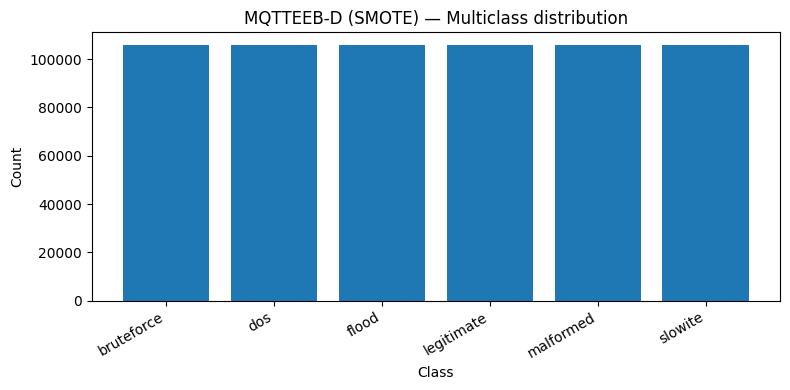

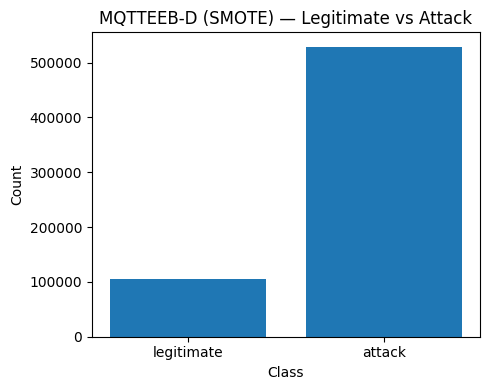

Target
0    105774
1    105774
2    105774
3    105774
4    105774
5    105774
Name: count, dtype: int64

Target
legitimate    105774
attack        528870
Name: count, dtype: int64

In [2]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

# --------------------
# Config
# --------------------
DATA_DIR = Path("Dataset/Preprocessed_Data")
TARGET_COL = "Target"

LABEL2ID = {
    "bruteforce": 0,
    "dos": 1,
    "flood": 2,
    "legitimate": 3,
    "malformed": 4,
    "slowite": 5
}
ID2LABEL = {v: k for k, v in LABEL2ID.items()}
ALL_IDS = list(range(len(LABEL2ID)))
LEGIT_ID = LABEL2ID["legitimate"]


# --------------------
# Helpers
# --------------------
def load_dataset(filename: str) -> pd.DataFrame:
    path = DATA_DIR / filename
    df = pd.read_csv(path)
    df[TARGET_COL] = pd.to_numeric(df[TARGET_COL], errors="raise")
    print(f"{filename}: shape={df.shape}")
    return df

def plot_multiclass(df: pd.DataFrame, title: str):
    counts = df[TARGET_COL].value_counts().reindex(ALL_IDS, fill_value=0).sort_index()
    labels = [ID2LABEL[i] for i in counts.index]

    plt.figure(figsize=(8, 4))
    plt.bar(labels, counts.values)
    plt.title(title)
    plt.xlabel("Class")
    plt.ylabel("Count")
    plt.xticks(rotation=30, ha="right")
    plt.tight_layout()
    plt.show()
    return counts

def plot_binary_legitimate_vs_attack(df: pd.DataFrame, title: str):
    binary = df[TARGET_COL].apply(lambda y: "legitimate" if y == LEGIT_ID else "attack")
    counts = binary.value_counts().reindex(["legitimate", "attack"], fill_value=0)

    plt.figure(figsize=(5, 4))
    plt.bar(counts.index, counts.values)
    plt.title(title)
    plt.xlabel("Class")
    plt.ylabel("Count")
    plt.tight_layout()
    plt.show()
    return counts


# --------------------
# Run on both datasets
# --------------------
for filename, tag in [
    ("MQTTEEB-D_dataset_All_Processed.csv", "All Processed"),
    ("MQTTEEB-D_dataset_Processed_SMOTE.csv", "SMOTE"),
]:
    df = load_dataset(filename)
    display(df.head())  # if you're in Jupyter; otherwise: print(df.head())

    multi = plot_multiclass(df, f"MQTTEEB-D ({tag}) — Multiclass distribution")
    binary = plot_binary_legitimate_vs_attack(df, f"MQTTEEB-D ({tag}) — Legitimate vs Attack")

    display(multi)
    display(binary)


### Cell 2 — Build time deltas and clean loop boundaries

This cell creates **time-based features** without using absolute timestamps (to avoid time leakage):

* **Reload raw time columns if needed**
  If `timestamp` / `tcp_time_delta` were dropped earlier, we reload the processed CSV into `df_raw` so we can recompute time features safely.

* **Convert human timestamp → UTC epoch seconds**
  We parse strings like `9/9/2024 3:17:54 AM`, normalize spacing, convert to `datetime`, then to **epoch seconds** (`_ts_epoch_utc`).

* **Compute two delta signals**

  * `delta_from_timestamp_s`: difference between consecutive rows using the parsed timestamp
  * `delta_from_tcp_time_delta`: difference between consecutive rows using the dataset’s `tcp_time_delta` column
    (This lets us verify whether `tcp_time_delta` is consistent with real timestamps.)

* **Remove loop boundaries / broken timing**
  Since the dataset is concatenated from multiple capture sessions, there can be **large gaps** between runs.
  We detect those gaps using a threshold (`max(60s, 99.9th percentile)`) and mark them as `+inf`, then drop those rows.

Result: `df` becomes a cleaned, time-ordered dataset with two comparable delta columns we can use later for **inter-arrival style features**.


In [3]:
import numpy as np

# Make sure we still have the raw time columns available
need_cols = {"timestamp", "tcp_time_delta"}
if not need_cols.issubset(df.columns):
    csv_path = globals().get("CSV_PATH", Path("Dataset/Preprocessed_Data") / "MQTTEEB-D_dataset_All_Processed.csv")
    df_raw = pd.read_csv(csv_path)
else:
    df_raw = df.copy()

# --- 1) Delta from human-readable timestamp (UTC epoch seconds) ---
ts_clean = df_raw["timestamp"].astype(str).str.replace(r"\s+", " ", regex=True).str.strip()
ts = pd.to_datetime(ts_clean, errors="coerce", utc=True)

df_raw = df_raw[ts.notna()].copy()
ts = ts[ts.notna()]

df_raw["_ts_epoch_utc"] = ts.dt.tz_localize(None).astype("int64") / 1e9

# --- 2) Prepare tcp_time_delta as numeric (whatever it actually is) ---
df_raw["_tcp_time_delta_num"] = pd.to_numeric(df_raw["tcp_time_delta"], errors="coerce")

# Sort by real timestamp epoch so both deltas align in the same order
df_raw = df_raw.sort_values("_ts_epoch_utc").reset_index(drop=True)

# Compute both deltas
df_raw["delta_from_timestamp_s"] = df_raw["_ts_epoch_utc"].diff()
df_raw["delta_from_tcp_time_delta"] = df_raw["_tcp_time_delta_num"].diff()

# Mark loop boundaries / bad rows using the timestamp delta (keep zeros; timestamps are 1-second resolution)
q = df_raw["delta_from_timestamp_s"].dropna()
GAP_THRESHOLD_S = max(60.0, float(q.quantile(0.999)))  # tune later if needed

bad = (
    df_raw["delta_from_timestamp_s"].isna()
    | (df_raw["delta_from_timestamp_s"] < 0)
    | (df_raw["delta_from_timestamp_s"] > GAP_THRESHOLD_S)
)
df_raw.loc[bad, ["delta_from_timestamp_s", "delta_from_tcp_time_delta"]] = np.inf

# Drop boundary rows (+inf)
df = df_raw[(df_raw["delta_from_timestamp_s"] != np.inf) & (df_raw["delta_from_tcp_time_delta"] != np.inf)].copy()

print("GAP_THRESHOLD_S =", GAP_THRESHOLD_S)
df[["delta_from_timestamp_s", "delta_from_tcp_time_delta", "Target"]].head(20), df.shape


GAP_THRESHOLD_S = 60.0


(    delta_from_timestamp_s  delta_from_tcp_time_delta  Target
 1                 7.894787                   7.894787       3
 2                 0.194841                   0.194842       3
 3                 2.395404                   2.395404       3
 4                 2.662379                   2.662380       3
 5                 1.860208                   1.860208       3
 6                 0.212361                   0.212361       3
 7                 0.661011                   0.661011       3
 8                 0.089540                   0.089540       3
 9                 0.085329                   0.085329       3
 10                0.438208                   0.438208       3
 11                0.543304                   0.543304       3
 12                3.929666                   3.929666       3
 13                1.268629                   1.268629       3
 14                0.272292                   0.272292       3
 15                1.243690                   1.243690 

### Cell 3 — Data quality check + engineered timing/traffic features

This cell turns the cleaned dataframe into the **actual modeling dataset**:

* **Missing values report (quick data quality)**
  We count missing values per column and compute:

  * how many rows contain *any* missing value
  * the % of affected rows
    This tells us whether we can just impute missing values later or if we need to drop/clean columns.

* **Inter-Arrival Time (IAT)**
  We create `iat_s`, which is the **time since the previous message**.
  We reuse the already computed deltas (timestamp-based or tcp_time_delta-based) so we don’t depend on absolute time.

* **Message rate features (traffic intensity)**
  Using a time index (`_dt`) only for rolling operations, we compute message counts in trailing windows:

  * `msg_rate_1s`, `msg_rate_10s`, `msg_rate_60s`
    These help detect bursty behavior (e.g., flooding/DoS).

* **Rolling payload statistics**
  We define `payload_len` as a proxy using `tcp_len` (best available payload-like field here), then compute:

  * rolling mean and std in a **10s** window
    This captures sustained changes in packet/message sizes.

* **Binary target for binary experiments**
  We add `target_bin`: `0 = legitimate`, `1 = any attack`.
  (We keep the original multiclass `Target` for multiclass classification later.)

* **Cleanup to avoid leakage**
  We drop raw timestamp columns and the temporary datetime index after feature extraction.
  Result: a feature matrix that keeps **relative timing behavior** but not absolute timestamps.


In [4]:
import numpy as np

# ----------------------------
# 1) Missing values inspection
# ----------------------------
n_rows = len(df)

missing_by_col = df.isna().sum().sort_values(ascending=False)
missing_pct_by_col = (missing_by_col / n_rows * 100).round(3)

rows_with_any_missing = df.isna().any(axis=1).sum()
rows_with_any_missing_pct = round(rows_with_any_missing / n_rows * 100, 3)

print(f"Rows: {n_rows:,}")
print(f"Rows with ANY missing value: {rows_with_any_missing:,} ({rows_with_any_missing_pct}%)")
print("\nTop columns by missing count:")
display(pd.DataFrame({
    "missing_count": missing_by_col,
    "missing_pct": missing_pct_by_col
}).query("missing_count > 0").head(15))

# ----------------------------
# 2) Time base + IAT
# ----------------------------
# IAT (inter-arrival time) = time since previous message/packet

# Prefer using your already-computed delta (they were the same anyway)
if "delta_from_timestamp_s" in df.columns:
    df["iat_s"] = df["delta_from_timestamp_s"].astype("float64")
elif "delta_from_tcp_time_delta" in df.columns:
    df["iat_s"] = df["delta_from_tcp_time_delta"].astype("float64")
else:
    # Fallback: compute from parsed timestamp if needed
    ts_clean = df["timestamp"].astype(str).str.replace(r"\s+", " ", regex=True).str.strip()
    ts = pd.to_datetime(ts_clean, errors="coerce", utc=True)
    df = df[ts.notna()].copy()
    df["_ts_epoch_utc"] = (ts[ts.notna()].dt.tz_localize(None).astype("int64") / 1e9).astype("float64")
    df = df.sort_values("_ts_epoch_utc").reset_index(drop=True)
    df["iat_s"] = df["_ts_epoch_utc"].diff().astype("float64")

# Build a timestamp index ONLY for rolling calculations (we'll drop it after)
if "_ts_epoch_utc" in df.columns:
    t_epoch = pd.to_numeric(df["_ts_epoch_utc"], errors="coerce")
elif "timestamp" in df.columns:
    ts_clean = df["timestamp"].astype(str).str.replace(r"\s+", " ", regex=True).str.strip()
    ts = pd.to_datetime(ts_clean, errors="coerce", utc=True)
    t_epoch = (ts.dt.tz_localize(None).astype("int64") / 1e9).astype("float64")
else:
    # If we truly have no timestamps left, reconstruct a relative timeline from IAT
    t_epoch = df["iat_s"].fillna(0).cumsum()

df["_dt"] = pd.to_datetime(t_epoch, unit="s", utc=True)

# Sort by time to make rolling windows correct
df = df.sort_values("_dt").reset_index(drop=True).set_index("_dt")

# ----------------------------
# 3) Message rate features (counts per window)
# ----------------------------
ones = pd.Series(1, index=df.index)

df["msg_rate_1s"]  = ones.rolling("1s").sum()
df["msg_rate_10s"] = ones.rolling("10s").sum()
df["msg_rate_60s"] = ones.rolling("60s").sum()

# ----------------------------
# 4) Rolling mean/std of payload length
# ----------------------------
# In this processed dataset, the closest reliable payload-length proxy is tcp_len.
# We'll call it payload_len for the assignment features.
if "tcp_len" not in df.columns:
    raise KeyError("Expected 'tcp_len' to exist to derive payload_len. Check your dataframe columns.")

df["payload_len"] = pd.to_numeric(df["tcp_len"], errors="coerce").astype("float64")

# Time-based rolling stats (10s window; you can change to '60s' etc.)
df["payload_len_roll_mean_10s"] = df["payload_len"].rolling("10s").mean()
df["payload_len_roll_std_10s"]  = df["payload_len"].rolling("10s").std()

# ----------------------------
# 5) Binary target
# ----------------------------
LEGIT_ID = 3  # your encoding: legitimate=3
df["target_bin"] = (df["Target"] != LEGIT_ID).astype("int64")

# ----------------------------
# 6) Cleanup: drop raw timestamps (keep deltas + engineered features)
# ----------------------------
df = df.reset_index()  # bring _dt back as a normal column temporarily
df.drop(columns=[c for c in ["timestamp", "tcp_time_delta", "_ts_epoch_utc", "_tcp_time_delta_num"] if c in df.columns],
        inplace=True)

# If you don't want the datetime column either (it can leak time), drop it:
df.drop(columns=["_dt"], inplace=True, errors="ignore")

# display(df[["iat_s", "msg_rate_1s", "msg_rate_10s", "msg_rate_60s",
#             "payload_len_roll_mean_10s", "payload_len_roll_std_10s",
#             "Target", "target_bin"]].head(10))

display(df.head(20))

df[["Target", "target_bin"]].value_counts().head(10)


Rows: 634,641
Rows with ANY missing value: 0 (0.0%)

Top columns by missing count:


,missing_count,missing_pct


,tcp_flags,tcp_len,mqtt_conack_flags,mqtt_conflag_cleansess,mqtt_conflags,mqtt_dupflag,mqtt_hdrflags,mqtt_kalive,mqtt_msg,mqtt_qos,...,delta_from_timestamp_s,delta_from_tcp_time_delta,iat_s,msg_rate_1s,msg_rate_10s,msg_rate_60s,payload_len,payload_len_roll_mean_10s,payload_len_roll_std_10s,target_bin
0,24,616,0,0.0,0,0.0,53,0,37372,2.0,...,7.894787,7.894787,7.894787,1.0,1.0,1.0,616.0,616.000000,NaN,0
1,24,610,0,0.0,0,0.0,53,0,37372,2.0,...,0.194841,0.194842,0.194841,2.0,2.0,2.0,610.0,613.000000,4.242641,0
2,24,609,0,0.0,0,0.0,53,0,37373,2.0,...,2.395404,2.395404,2.395404,1.0,3.0,3.0,609.0,611.666667,3.785939,0
3,24,610,0,0.0,0,0.0,53,0,37373,2.0,...,2.662379,2.662380,2.662379,1.0,4.0,4.0,610.0,611.250000,3.201562,0
4,24,611,0,0.0,0,0.0,53,0,37373,2.0,...,1.860208,1.860208,1.860208,1.0,5.0,5.0,611.0,611.200000,2.774887,0
5,24,610,0,0.0,0,0.0,53,0,37373,2.0,...,0.212361,0.212361,0.212361,2.0,6.0,6.0,610.0,611.000000,2.529822,0
6,24,611,0,0.0,0,0.0,53,0,37373,2.0,...,0.661011,0.661011,0.661011,3.0,7.0,7.0,611.0,611.000000,2.309401,0
7,24,614,0,0.0,0,0.0,53,0,37373,2.0,...,0.089540,0.089540,0.089540,4.0,8.0,8.0,614.0,611.375000,2.386719,0
8,24,615,0,0.0,0,0.0,53,0,37373,2.0,...,0.085329,0.085329,0.085329,4.0,9.0,9.0,615.0,611.777778,2.538591,0
9,24,615,0,0.0,0,0.0,53,0,37373,2.0,...,0.438208,0.438208,0.438208,4.0,10.0,10.0,615.0,612.100000,2.601282,0


Target  target_bin
0       1             105774
1       1             105774
2       1             105774
4       1             105774
5       1             105774
3       0             105771
Name: count, dtype: int64

### Cell 4 — Key feature visualization (distributions + correlation)

This cell adds the **mandatory “visualization of key features”** part:

* **Pick key features**
  We focus on the features we engineered (`iat_s`, message rates, rolling payload stats) plus `tcp_len`, since these are most likely to reflect attack behavior.

* **Binary grouping for visualization**
  We create `class_bin` (`legitimate` vs `attack`) just for plotting, to see if features separate the two groups.

* **Histogram overlays (legitimate vs attack)**
  For each key feature, we plot two histograms on the same chart.
  Using a **log y-scale** makes heavy-tailed traffic features readable (otherwise the plot is dominated by the peak).
  These plots help judge whether a feature has **signal** (different distributions) or is mostly noise.

* **Correlation heatmap (numeric only)**
  We compute a correlation matrix to spot strongly correlated features (redundancy) and potential multicollinearity.
  This is not “feature importance”, but it helps understand the feature space before modeling.


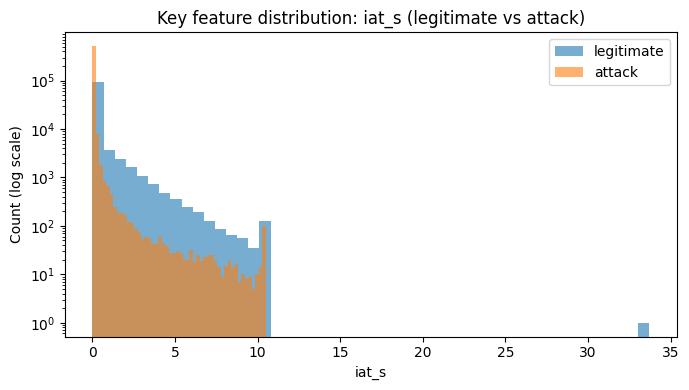

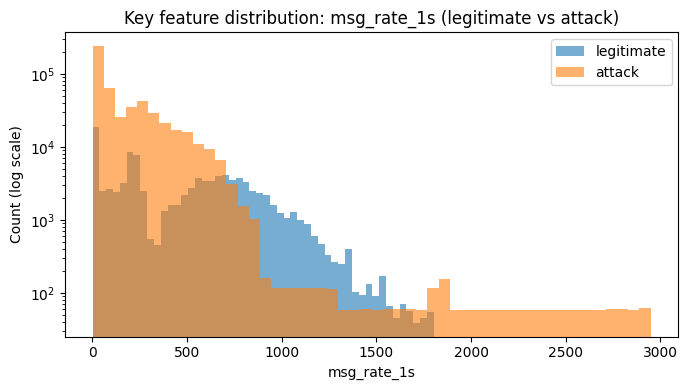

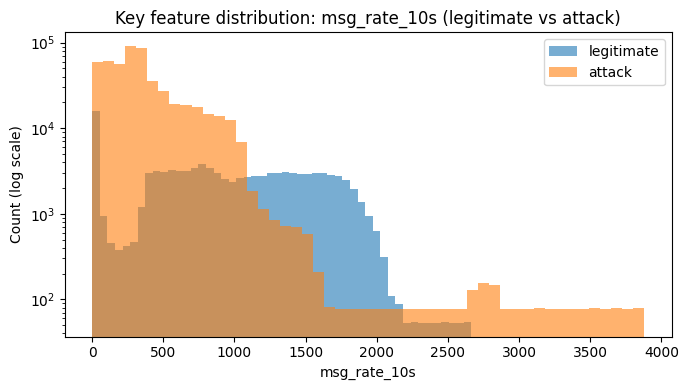

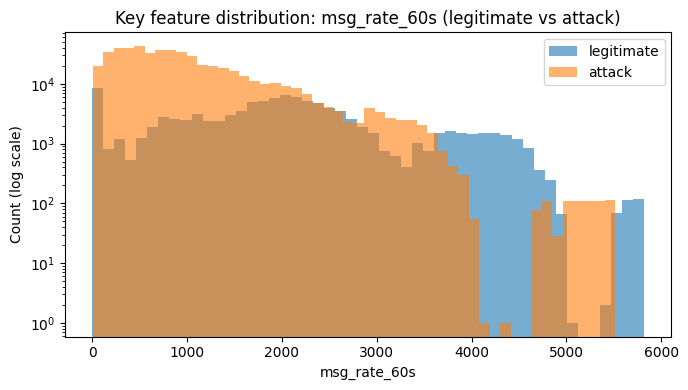

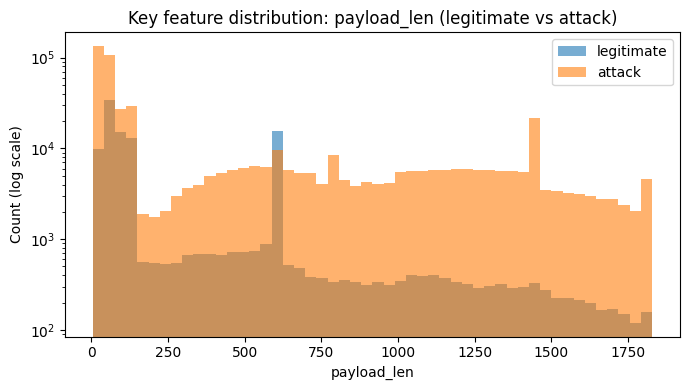

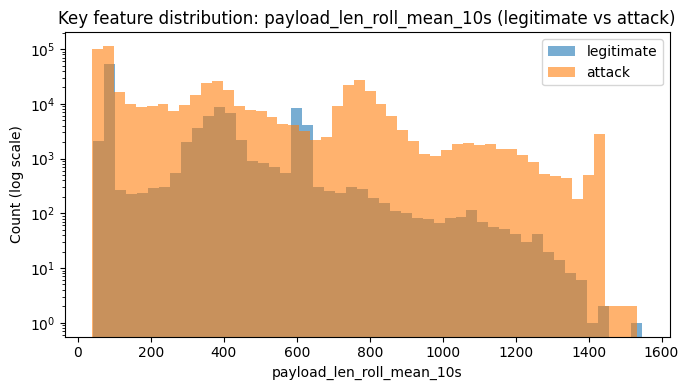

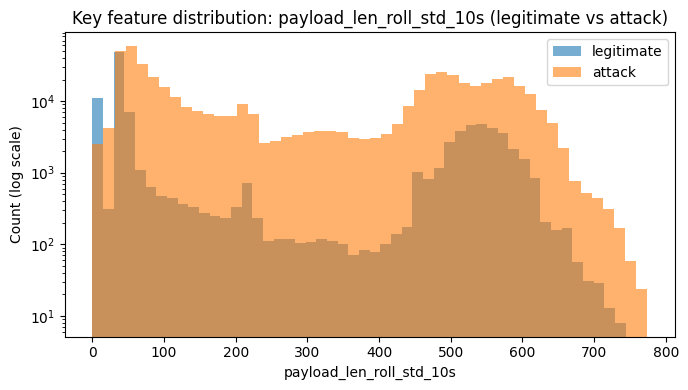

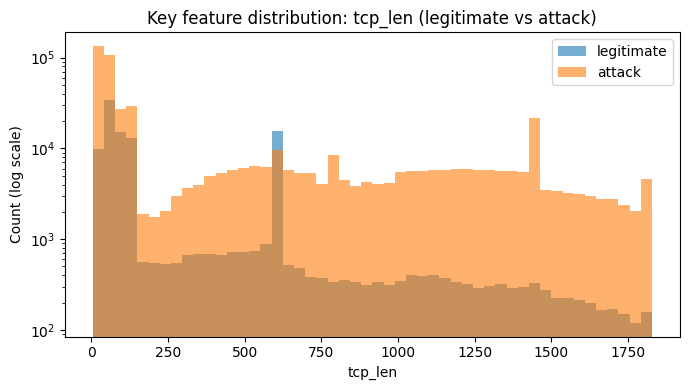

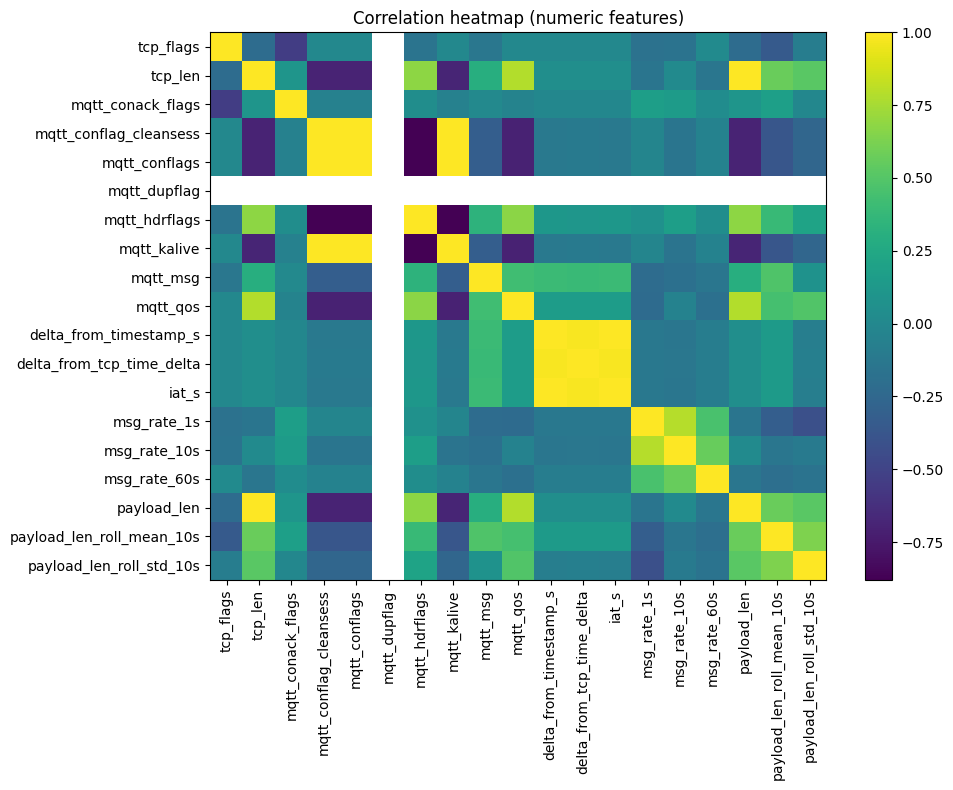

In [5]:
# Visualization of "key features" (simple, assignment-friendly)
# Shows how important features differ across classes.

import matplotlib.pyplot as plt

# pick a few features we engineered + a couple raw ones
key_features = [
    "iat_s",
    "msg_rate_1s", "msg_rate_10s", "msg_rate_60s",
    "payload_len", "payload_len_roll_mean_10s", "payload_len_roll_std_10s",
    "tcp_len"
]
key_features = [c for c in key_features if c in df.columns]

LEGIT_ID = 3
df["class_bin"] = np.where(df["Target"] == LEGIT_ID, "legitimate", "attack")

# 1) Histograms (legitimate vs attack)
for col in key_features:
    plt.figure(figsize=(7, 4))
    plt.hist(df.loc[df["class_bin"] == "legitimate", col].dropna(), bins=50, alpha=0.6, label="legitimate")
    plt.hist(df.loc[df["class_bin"] == "attack", col].dropna(), bins=50, alpha=0.6, label="attack")
    plt.yscale("log")  # traffic features are usually long-tailed
    plt.title(f"Key feature distribution: {col} (legitimate vs attack)")
    plt.xlabel(col)
    plt.ylabel("Count (log scale)")
    plt.legend()
    plt.tight_layout()
    plt.show()

# 2) Correlation heatmap (numeric features only)
numeric = df.select_dtypes(include="number").drop(columns=["Target", "target_bin"], errors="ignore")
corr = numeric.corr(numeric_only=True)

plt.figure(figsize=(10, 8))
plt.imshow(corr, aspect="auto")
plt.title("Correlation heatmap (numeric features)")
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.index)), corr.index)
plt.colorbar()
plt.tight_layout()
plt.show()


### Cell 5 — Binary XGBoost baseline (time-aware split + learning curves)

This cell trains the first real model: a **binary attack detector** (`legitimate` vs `attack`).

* **Binary target + features**

  * `y = target_bin` (0 = legitimate, 1 = attack)
  * `X` uses only numeric features (drops `Target` and `target_bin`)

* **Time-aware splitting (required)**

  * Train = earliest 70%
  * Validation = next 10%
  * Test = final 20%
    This avoids “future leakage” and better simulates deployment.

* **Imbalance handling**
  We compute `scale_pos_weight = neg/pos` so XGBoost doesn’t ignore the minority class (legitimate or attack depending on distribution).

* **Training with early stopping**
  We train with validation monitoring and stop when validation loss stops improving (version-safe callback logic).

* **Plots**

  * **Logloss curve**: checks convergence and overfitting (train vs val divergence).
  * **F1 curve (every few boosting rounds)**: shows how classification quality evolves, not just loss.

* **Final evaluation**
  We report **precision, recall, F1 on the test split** using the best iteration selected by validation.


xgboost: 3.1.2
scale_pos_weight = 0.20642196852018815
[0]	validation_0-logloss:0.65471	validation_1-logloss:0.65385
[50]	validation_0-logloss:0.14901	validation_1-logloss:0.14954
[100]	validation_0-logloss:0.09516	validation_1-logloss:0.10276
[150]	validation_0-logloss:0.07508	validation_1-logloss:0.08907
[200]	validation_0-logloss:0.06356	validation_1-logloss:0.08205
[250]	validation_0-logloss:0.05489	validation_1-logloss:0.07901
[300]	validation_0-logloss:0.04884	validation_1-logloss:0.07652
[350]	validation_0-logloss:0.04428	validation_1-logloss:0.07530
[400]	validation_0-logloss:0.03970	validation_1-logloss:0.07382
[450]	validation_0-logloss:0.03651	validation_1-logloss:0.07320
[500]	validation_0-logloss:0.03373	validation_1-logloss:0.07283
[550]	validation_0-logloss:0.03144	validation_1-logloss:0.07272
[600]	validation_0-logloss:0.02943	validation_1-logloss:0.07258
[650]	validation_0-logloss:0.02766	validation_1-logloss:0.07312
[700]	validation_0-logloss:0.02619	validation_1-loglo

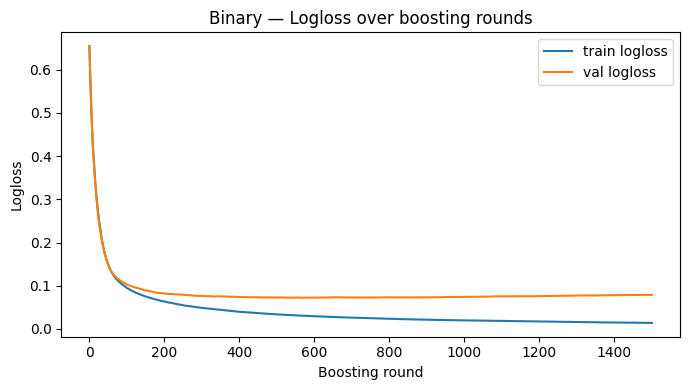

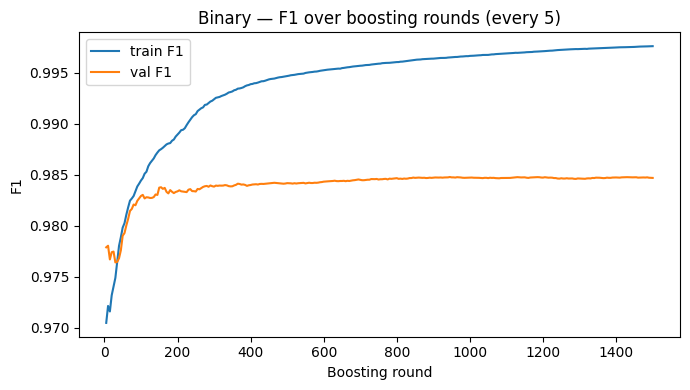

TEST Precision: 0.9712569093967797
TEST Recall:    0.9472356862267141
TEST F1:        0.9590959143377886


In [6]:
import numpy as np
import matplotlib.pyplot as plt
import xgboost as xgb
import inspect
from sklearn.metrics import f1_score, precision_score, recall_score

print("xgboost:", xgb.__version__)

# X / y
y = df["target_bin"].astype(int).values
X = df.select_dtypes(include="number").drop(columns=["Target", "target_bin"], errors="ignore")

# time-aware split (assumes df already ordered by time)
n = len(df)
i_train = int(0.70 * n)
i_val   = int(0.80 * n)

X_train, y_train = X.iloc[:i_train], y[:i_train]
X_val,   y_val   = X.iloc[i_train:i_val], y[i_train:i_val]
X_test,  y_test  = X.iloc[i_val:], y[i_val:]

# imbalance weight (attack=1)
pos = int((y_train == 1).sum())
neg = int((y_train == 0).sum())
scale_pos_weight = (neg / pos) if pos > 0 else 1.0
print("scale_pos_weight =", scale_pos_weight)

# early stopping compatibility
fit_sig = inspect.signature(xgb.XGBClassifier.fit)
use_callbacks = "callbacks" in fit_sig.parameters
callbacks = [xgb.callback.EarlyStopping(rounds=50)] if use_callbacks else None

clf_bin = xgb.XGBClassifier(
    n_estimators=1500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="binary:logistic",
    eval_metric="logloss",
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    tree_method="hist",
)

fit_kwargs = dict(eval_set=[(X_train, y_train), (X_val, y_val)], verbose=50)
if use_callbacks:
    fit_kwargs["callbacks"] = callbacks

clf_bin.fit(X_train, y_train, **fit_kwargs)

evals = clf_bin.evals_result()
train_loss = evals["validation_0"]["logloss"]
val_loss   = evals["validation_1"]["logloss"]

# best iteration (0-based) if available; otherwise last
best_iter = getattr(clf_bin, "best_iteration", None)
if best_iter is None:
    best_iter = len(val_loss) - 1
print("Best iteration:", best_iter)

# Plot: loss
rounds = np.arange(1, len(train_loss) + 1)
plt.figure(figsize=(7,4))
plt.plot(rounds, train_loss, label="train logloss")
plt.plot(rounds, val_loss, label="val logloss")
plt.title("Binary — Logloss over boosting rounds")
plt.xlabel("Boosting round")
plt.ylabel("Logloss")
plt.legend()
plt.tight_layout()
plt.show()

# Plot: F1 over time (every STEP rounds)
booster = clf_bin.get_booster()
dtrain = xgb.DMatrix(X_train)
dval   = xgb.DMatrix(X_val)

def predict_up_to(booster, dmat, r):
    try:
        return booster.predict(dmat, iteration_range=(0, r))
    except TypeError:
        return booster.predict(dmat, ntree_limit=r)

STEP = 5
rr, f1_tr, f1_va = [], [], []
for r in range(STEP, best_iter + 2, STEP):
    p_tr = predict_up_to(booster, dtrain, r)
    p_va = predict_up_to(booster, dval,   r)
    f1_tr.append(f1_score(y_train, (p_tr >= 0.5).astype(int)))
    f1_va.append(f1_score(y_val,   (p_va >= 0.5).astype(int)))
    rr.append(r)

plt.figure(figsize=(7,4))
plt.plot(rr, f1_tr, label="train F1")
plt.plot(rr, f1_va, label="val F1")
plt.title(f"Binary — F1 over boosting rounds (every {STEP})")
plt.xlabel("Boosting round")
plt.ylabel("F1")
plt.legend()
plt.tight_layout()
plt.show()

# Test metrics using best_iter
dtest = xgb.DMatrix(X_test)
p_test = predict_up_to(booster, dtest, best_iter + 1)
yhat_test = (p_test >= 0.5).astype(int)

print("TEST Precision:", precision_score(y_test, yhat_test, zero_division=0))
print("TEST Recall:   ", recall_score(y_test, yhat_test, zero_division=0))
print("TEST F1:       ", f1_score(y_test, yhat_test, zero_division=0))


### Cell 6 — Multiclass XGBoost + per-attack evaluation + model saving

This cell upgrades the baseline from binary detection to **full multiclass classification** (6 classes).

* **Multiclass target**

  * `y = Target` (0..5), predicting the exact attack type + legitimate.

* **Time-aware split (same policy)**
  Train/Val/Test = 70% / 10% / 20% in chronological order.

* **Class imbalance handling (multiclass)**
  We compute **balanced class weights** from the training split and pass them as `sample_weight`.
  This reduces bias toward majority classes.

* **Training + early stopping**
  XGBoost is trained with `multi:softprob` and validation monitoring.
  Early stopping logic is kept version-safe via callbacks.

* **Plots**

  * **mlogloss curve**: checks convergence and overfitting for multiclass.
  * **macro-F1 curve**: shows performance averaged across classes, which is more meaningful under imbalance.

* **Test evaluation**
  We report:

  * **Macro-F1** (treats each class equally)
  * **Weighted-F1** (weights by class frequency)
  * **Per-class precision/recall/F1** (mandatory “per attack type” breakdown, includes legitimate)

* **Model export**
  We save the trained booster to `models/xgb_multiclass.json` so later cells (feature importance + streaming IDS pipeline) can load and reuse it without retraining.


xgboost: 3.1.2
[0]	validation_0-mlogloss:1.67328	validation_1-mlogloss:1.67345
[50]	validation_0-mlogloss:0.28741	validation_1-mlogloss:0.29121
[100]	validation_0-mlogloss:0.16253	validation_1-mlogloss:0.17398
[150]	validation_0-mlogloss:0.12925	validation_1-mlogloss:0.14850
[200]	validation_0-mlogloss:0.11158	validation_1-mlogloss:0.13845
[250]	validation_0-mlogloss:0.09894	validation_1-mlogloss:0.13451
[300]	validation_0-mlogloss:0.08914	validation_1-mlogloss:0.13196
[350]	validation_0-mlogloss:0.08161	validation_1-mlogloss:0.13106
[400]	validation_0-mlogloss:0.07554	validation_1-mlogloss:0.13085
[450]	validation_0-mlogloss:0.07046	validation_1-mlogloss:0.13191
[500]	validation_0-mlogloss:0.06602	validation_1-mlogloss:0.13264
[550]	validation_0-mlogloss:0.06232	validation_1-mlogloss:0.13388
[600]	validation_0-mlogloss:0.05917	validation_1-mlogloss:0.13583
[650]	validation_0-mlogloss:0.05642	validation_1-mlogloss:0.13700
[700]	validation_0-mlogloss:0.05394	validation_1-mlogloss:0.1379

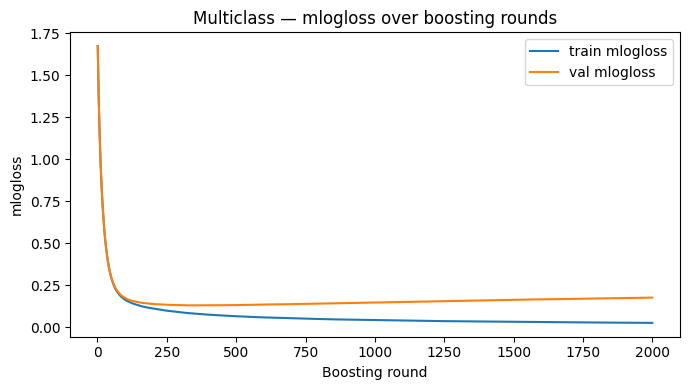

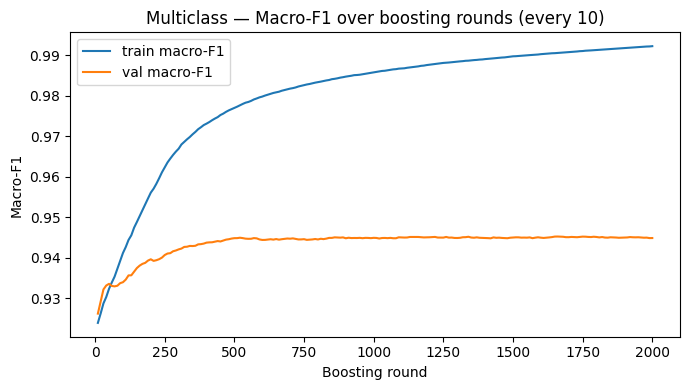

TEST Macro-F1: 0.8802366272057971
TEST Weighted-F1: 0.8789018775339906


,precision,recall,f1-score,support
bruteforce,0.869427,0.808216,0.837705,22030.0
dos,0.800513,0.868709,0.833218,19392.0
flood,0.996610,0.947832,0.971609,17367.0
legitimate,0.751247,0.847034,0.796271,20266.0
malformed,0.978007,0.943309,0.960345,21732.0
slowite,0.900989,0.864318,0.882273,26142.0


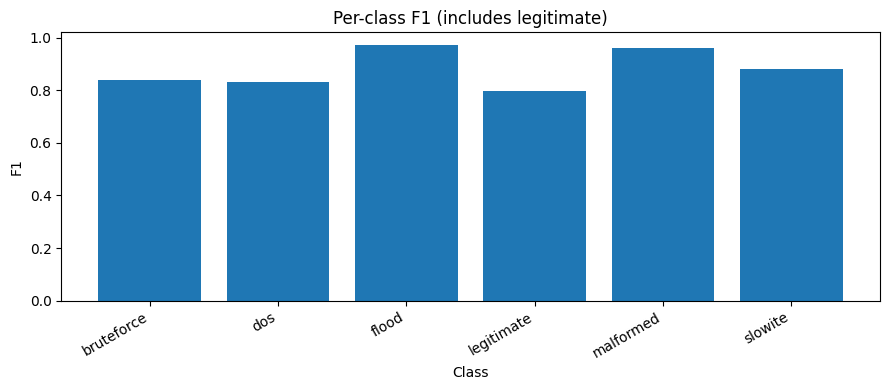

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import xgboost as xgb
import inspect

from sklearn.metrics import f1_score, classification_report
from sklearn.utils.class_weight import compute_class_weight

print("xgboost:", xgb.__version__)

# label mapping for consistent plots
LABEL2ID = {"bruteforce": 0, "dos": 1, "flood": 2, "legitimate": 3, "malformed": 4, "slowite": 5}
ID2LABEL = {v: k for k, v in LABEL2ID.items()}
class_ids = list(range(6))
class_names = [ID2LABEL[i] for i in class_ids]

# X / y
y = df["Target"].astype(int).values
X = df.select_dtypes(include="number").drop(columns=["Target", "target_bin"], errors="ignore")

# time-aware split
n = len(df)
i_train = int(0.70 * n)
i_val   = int(0.80 * n)

X_train, y_train = X.iloc[:i_train], y[:i_train]
X_val,   y_val   = X.iloc[i_train:i_val], y[i_train:i_val]
X_test,  y_test  = X.iloc[i_val:], y[i_val:]

# class weights (helps imbalance)
present = np.unique(y_train)
cw = compute_class_weight(class_weight="balanced", classes=present, y=y_train)
cw_map = dict(zip(present, cw))
w_train = np.array([cw_map[c] for c in y_train], dtype=float)
w_val   = np.array([cw_map.get(c, 1.0) for c in y_val], dtype=float)

# early stopping compatibility
fit_sig = inspect.signature(xgb.XGBClassifier.fit)
use_callbacks = "callbacks" in fit_sig.parameters
callbacks = [xgb.callback.EarlyStopping(rounds=50)] if use_callbacks else None

clf_multi = xgb.XGBClassifier(
    n_estimators=2000,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="multi:softprob",
    num_class=6,
    eval_metric="mlogloss",
    random_state=42,
    tree_method="hist",
)

fit_kwargs = dict(
    eval_set=[(X_train, y_train), (X_val, y_val)],
    verbose=50,
    sample_weight=w_train
)

# sample_weight_eval_set might not exist in older/newer versions; only add if supported
if "sample_weight_eval_set" in fit_sig.parameters:
    fit_kwargs["sample_weight_eval_set"] = [w_train, w_val]
if use_callbacks:
    fit_kwargs["callbacks"] = callbacks

clf_multi.fit(X_train, y_train, **fit_kwargs)

evals = clf_multi.evals_result()
tr_loss = evals["validation_0"]["mlogloss"]
va_loss = evals["validation_1"]["mlogloss"]

best_iter = getattr(clf_multi, "best_iteration", None)
if best_iter is None:
    best_iter = len(va_loss) - 1
print("Best iteration:", best_iter)

# Plot: loss
rounds = np.arange(1, len(tr_loss) + 1)
plt.figure(figsize=(7,4))
plt.plot(rounds, tr_loss, label="train mlogloss")
plt.plot(rounds, va_loss, label="val mlogloss")
plt.title("Multiclass — mlogloss over boosting rounds")
plt.xlabel("Boosting round")
plt.ylabel("mlogloss")
plt.legend()
plt.tight_layout()
plt.show()

# Plot: macro-F1 over time (every STEP rounds)
booster = clf_multi.get_booster()
dtrain = xgb.DMatrix(X_train)
dval   = xgb.DMatrix(X_val)

def predict_up_to(booster, dmat, r):
    try:
        return booster.predict(dmat, iteration_range=(0, r))
    except TypeError:
        return booster.predict(dmat, ntree_limit=r)

STEP = 10
rr, f1_tr, f1_va = [], [], []
for r in range(STEP, best_iter + 2, STEP):
    p_tr = predict_up_to(booster, dtrain, r)
    p_va = predict_up_to(booster, dval,   r)
    yhat_tr = np.argmax(p_tr, axis=1)
    yhat_va = np.argmax(p_va, axis=1)
    f1_tr.append(f1_score(y_train, yhat_tr, average="macro", zero_division=0))
    f1_va.append(f1_score(y_val,   yhat_va, average="macro", zero_division=0))
    rr.append(r)

plt.figure(figsize=(7,4))
plt.plot(rr, f1_tr, label="train macro-F1")
plt.plot(rr, f1_va, label="val macro-F1")
plt.title(f"Multiclass — Macro-F1 over boosting rounds (every {STEP})")
plt.xlabel("Boosting round")
plt.ylabel("Macro-F1")
plt.legend()
plt.tight_layout()
plt.show()

# Test predictions @ best_iter
dtest = xgb.DMatrix(X_test)
p_test = predict_up_to(booster, dtest, best_iter + 1)
yhat_test = np.argmax(p_test, axis=1)

print("TEST Macro-F1:", f1_score(y_test, yhat_test, average="macro", zero_division=0))
print("TEST Weighted-F1:", f1_score(y_test, yhat_test, average="weighted", zero_division=0))

# Per-class (per-attack-type) report INCLUDING legitimate
rep = classification_report(
    y_test, yhat_test,
    labels=class_ids,
    target_names=class_names,
    output_dict=True,
    zero_division=0
)
per_class = pd.DataFrame({k: rep[k] for k in class_names}).T[["precision", "recall", "f1-score", "support"]]
display(per_class)

plt.figure(figsize=(9,4))
plt.bar(per_class.index, per_class["f1-score"].values)
plt.title("Per-class F1 (includes legitimate)")
plt.xlabel("Class")
plt.ylabel("F1")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

# ---- where to save ----
MODEL_DIR = Path("models")
MODEL_DIR.mkdir(parents=True, exist_ok=True)

MODEL_PATH = MODEL_DIR / "xgb_multiclass.json"
META_PATH  = MODEL_DIR / "xgb_multiclass_meta.json"

# ---- save the trained booster ----
booster = clf_multi.get_booster()
booster.save_model(MODEL_PATH.as_posix())


In [8]:
import json
from pathlib import Path
import xgboost as xgb

MODEL_PATH = Path("models/xgb_multiclass.json")
META_PATH  = Path("models/xgb_multiclass_meta.json")

# meta = json.loads(META_PATH.read_text())
# best_iter = meta["best_iteration"]
# feature_names = meta["feature_names"]

booster = xgb.Booster()
booster.load_model(MODEL_PATH.as_posix())

print("Loaded booster. best_iter =", best_iter)


Loaded booster. best_iter = 1999


### Cell 7 — Sequence preparation for LSTM (multiclass)

This cell prepares the dataset for sequence models (LSTM/LSTM-AE), since LSTMs need **windows of packets**, not independent rows.

* **Time-aware split (same policy)**
  We keep the 70% / 10% / 20% chronological split so the sequence model is trained on “past” traffic and evaluated on “future” traffic.

* **Imputation + scaling (train-only fit)**
  We fill missing values with the training median and standardize features using training statistics.
  This prevents leakage from validation/test into the preprocessing stage.

* **Sliding window sequence construction**
  We build sequences of length `SEQ_LEN`:

  * input: `X[i-SEQ_LEN+1 : i+1]`
  * label: `y[i]` (class of the last element in the window)
    This gives a sequence classification setup that approximates “recent context → current decision”.

* **No boundary crossing**
  Sequences are built separately for train/val/test splits, so we never create windows that include future samples from another split.

Output: `X_*_seq` shaped `(num_sequences, SEQ_LEN, num_features)` and matching multiclass labels for LSTM training.


In [9]:
import numpy as np
import pandas as pd

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

# ---- config ----
SEQ_LEN = 30        # try 20/30/50
BATCH_SIZE = 256

# class mapping (fixed)
LABEL2ID = {"bruteforce": 0, "dos": 1, "flood": 2, "legitimate": 3, "malformed": 4, "slowite": 5}
ID2LABEL = {v: k for k, v in LABEL2ID.items()}
NUM_CLASSES = 6

# ---- X/y (numeric only, no labels) ----
y_all = df["Target"].astype(int).values
X_all = df.select_dtypes(include="number").drop(columns=["Target", "target_bin"], errors="ignore")

# ---- time-aware split by row order (assumes df is already chronological) ----
n = len(df)
i_train = int(0.70 * n)
i_val   = int(0.80 * n)

X_train_raw, y_train = X_all.iloc[:i_train], y_all[:i_train]
X_val_raw,   y_val   = X_all.iloc[i_train:i_val], y_all[i_train:i_val]
X_test_raw,  y_test  = X_all.iloc[i_val:], y_all[i_val:]

print("Raw split sizes:", X_train_raw.shape, X_val_raw.shape, X_test_raw.shape)

# ---- impute + scale (fit ONLY on train) ----
imputer = SimpleImputer(strategy="median")
scaler  = StandardScaler()

X_train = scaler.fit_transform(imputer.fit_transform(X_train_raw))
X_val   = scaler.transform(imputer.transform(X_val_raw))
X_test  = scaler.transform(imputer.transform(X_test_raw))

# ---- make sequences WITHOUT crossing boundaries ----
def make_sequences(X, y, seq_len):
    # label = class at last timestep of the window
    Xs, ys = [], []
    for i in range(seq_len - 1, len(X)):
        Xs.append(X[i-seq_len+1:i+1])
        ys.append(y[i])
    return np.asarray(Xs, dtype=np.float32), np.asarray(ys, dtype=np.int64)

X_train_seq, y_train_seq = make_sequences(X_train, y_train, SEQ_LEN)
X_val_seq,   y_val_seq   = make_sequences(X_val,   y_val,   SEQ_LEN)
X_test_seq,  y_test_seq  = make_sequences(X_test,  y_test,  SEQ_LEN)

print("Seq split sizes:", X_train_seq.shape, X_val_seq.shape, X_test_seq.shape)
print("Num features:", X_train_seq.shape[-1])


Raw split sizes: (444248, 19) (63464, 19) (126929, 19)
Seq split sizes: (444219, 30, 19) (63435, 30, 19) (126900, 30, 19)
Num features: 19


### Cell 8 — LSTM multiclass classifier (sequence model + training curves)

This cell trains a **sequence-based** multiclass model using the windows built in the previous cell.

* **Why LSTM here**
  XGBoost treats rows independently. The LSTM uses **recent context** (last `SEQ_LEN` packets) to classify the current packet, which can help for attacks that show temporal patterns.

* **DataLoaders**
  We wrap `(X_seq, y_seq)` into PyTorch `DataLoader`s for efficient minibatch training on CPU/GPU.

* **Class imbalance handling**
  We compute class weights from the training sequences and use them in `CrossEntropyLoss`.
  This pushes the model to not ignore rare attack classes.

* **Model architecture**
  Simple LSTM encoder:

  * LSTM over sequence → take last hidden state
  * dropout → linear layer → 6 logits

* **Training loop**
  We train for `EPOCHS`, track loss + macro-F1 on train/val, and keep the **best validation macro-F1** checkpoint.

* **Graphs**

  * **Loss vs epoch**: checks optimization and overfitting (train vs val gap).
  * **Macro-F1 vs epoch**: main quality signal under imbalance.
  * **Per-class F1 vs epoch**: shows which classes improve and which remain weak (includes `legitimate`).

* **Final test evaluation**
  After restoring the best checkpoint, we evaluate on **TEST**:

  * Macro-F1 / Weighted-F1
  * Full per-class report + bar chart (mandatory per-attack breakdown).


device: cpu
train class counts: [73107 76533 77865 75983 73599 67132]
class weights: [1.013 0.967 0.951 0.974 1.006 1.103]
Epoch 01/15 | train loss 0.2931 val loss 0.2303 | train F1 0.8753 val F1 0.9021
Epoch 02/15 | train loss 0.1882 val loss 0.1674 | train F1 0.9200 val F1 0.9339
Epoch 03/15 | train loss 0.1518 val loss 0.1530 | train F1 0.9375 val F1 0.9355
Epoch 04/15 | train loss 0.1378 val loss 0.1527 | train F1 0.9440 val F1 0.9426
Epoch 05/15 | train loss 0.1264 val loss 0.1568 | train F1 0.9488 val F1 0.9413
Epoch 06/15 | train loss 0.1194 val loss 0.1465 | train F1 0.9524 val F1 0.9439
Epoch 07/15 | train loss 0.1146 val loss 0.1519 | train F1 0.9538 val F1 0.9437
Epoch 08/15 | train loss 0.1077 val loss 0.1537 | train F1 0.9562 val F1 0.9467
Epoch 09/15 | train loss 0.1028 val loss 0.1541 | train F1 0.9586 val F1 0.9462
Epoch 10/15 | train loss 0.0994 val loss 0.1812 | train F1 0.9603 val F1 0.9398
Epoch 11/15 | train loss 0.0946 val loss 0.1862 | train F1 0.9617 val F1 0.94

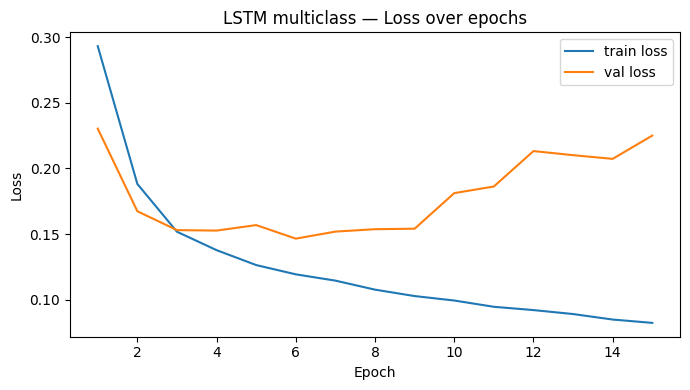

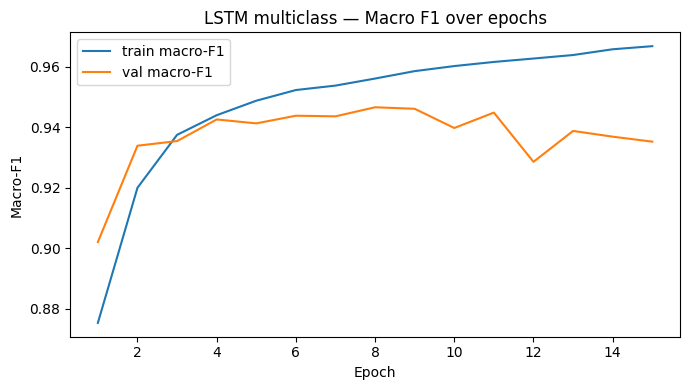

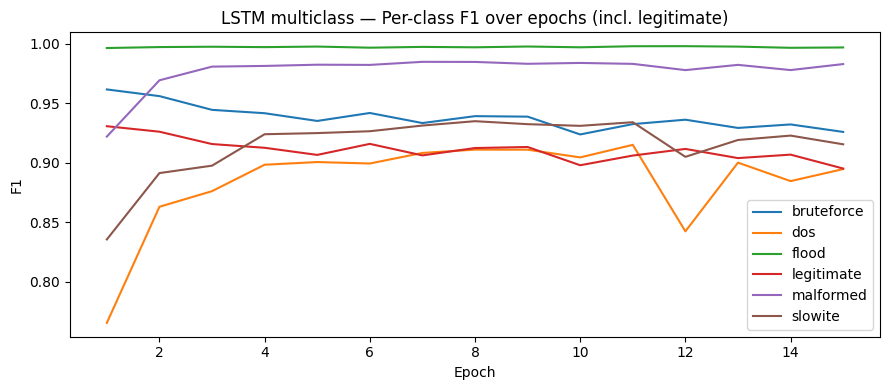

TEST Macro-F1: 0.8955698437275584
TEST Weighted-F1: 0.895253096555031

Per-class report (includes legitimate):
              precision    recall  f1-score   support

  bruteforce       0.87      0.85      0.86     22030
         dos       0.85      0.88      0.86     19392
       flood       0.99      0.92      0.96     17367
  legitimate       0.81      0.84      0.82     20266
   malformed       0.98      0.95      0.97     21732
     slowite       0.89      0.93      0.91     26113

    accuracy                           0.89    126900
   macro avg       0.90      0.89      0.90    126900
weighted avg       0.90      0.89      0.90    126900



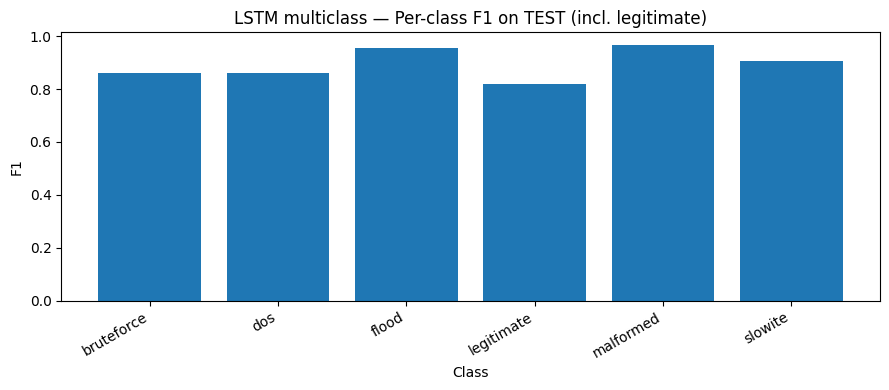

In [10]:
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

import matplotlib.pyplot as plt
from sklearn.metrics import f1_score, classification_report

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)

# ---- datasets/loaders ----
train_ds = TensorDataset(torch.from_numpy(X_train_seq), torch.from_numpy(y_train_seq))
val_ds   = TensorDataset(torch.from_numpy(X_val_seq),   torch.from_numpy(y_val_seq))
test_ds  = TensorDataset(torch.from_numpy(X_test_seq),  torch.from_numpy(y_test_seq))

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, drop_last=False)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, drop_last=False)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, drop_last=False)

# ---- class weights (helps imbalance) ----
counts = np.bincount(y_train_seq, minlength=NUM_CLASSES).astype(np.float32)
weights = (counts.sum() / (NUM_CLASSES * np.maximum(counts, 1.0)))
class_weights = torch.tensor(weights, dtype=torch.float32, device=device)
print("train class counts:", counts.astype(int))
print("class weights:", weights.round(3))

# ---- model ----
class LSTMClassifier(nn.Module):
    def __init__(self, n_features, hidden=128, layers=1, dropout=0.2, n_classes=6):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=n_features,
            hidden_size=hidden,
            num_layers=layers,
            batch_first=True,
            dropout=dropout if layers > 1 else 0.0
        )
        self.drop = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden, n_classes)

    def forward(self, x):
        # x: (B, T, F)
        out, (h_n, c_n) = self.lstm(x)
        h_last = h_n[-1]          # (B, hidden)
        logits = self.fc(self.drop(h_last))
        return logits

n_features = X_train_seq.shape[-1]
model = LSTMClassifier(n_features=n_features, hidden=128, layers=1, dropout=0.2, n_classes=NUM_CLASSES).to(device)

criterion = nn.CrossEntropyLoss(weight=class_weights)
optim = torch.optim.Adam(model.parameters(), lr=1e-3)

# ---- training helpers ----
def run_epoch(loader, train=True):
    model.train(train)
    total_loss = 0.0
    all_y, all_pred = [], []

    for xb, yb in loader:
        xb, yb = xb.to(device), yb.to(device)

        if train:
            optim.zero_grad()

        logits = model(xb)
        loss = criterion(logits, yb)

        if train:
            loss.backward()
            optim.step()

        total_loss += loss.item() * xb.size(0)
        preds = torch.argmax(logits, dim=1)
        all_y.append(yb.detach().cpu().numpy())
        all_pred.append(preds.detach().cpu().numpy())

    all_y = np.concatenate(all_y)
    all_pred = np.concatenate(all_pred)

    avg_loss = total_loss / len(loader.dataset)
    macro_f1 = f1_score(all_y, all_pred, average="macro", zero_division=0)
    per_class_f1 = f1_score(all_y, all_pred, average=None, labels=list(range(NUM_CLASSES)), zero_division=0)

    return avg_loss, macro_f1, per_class_f1

# ---- train loop ----
EPOCHS = 15
hist = {
    "train_loss": [], "val_loss": [],
    "train_macro_f1": [], "val_macro_f1": [],
    "val_per_class_f1": []   # shape: (epochs, 6)
}

best_val = -1
best_state = None

for epoch in range(1, EPOCHS + 1):
    tr_loss, tr_f1, _ = run_epoch(train_loader, train=True)
    va_loss, va_f1, va_pc = run_epoch(val_loader, train=False)

    hist["train_loss"].append(tr_loss)
    hist["val_loss"].append(va_loss)
    hist["train_macro_f1"].append(tr_f1)
    hist["val_macro_f1"].append(va_f1)
    hist["val_per_class_f1"].append(va_pc)

    if va_f1 > best_val:
        best_val = va_f1
        best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}

    print(f"Epoch {epoch:02d}/{EPOCHS} | "
          f"train loss {tr_loss:.4f} val loss {va_loss:.4f} | "
          f"train F1 {tr_f1:.4f} val F1 {va_f1:.4f}")

# restore best model
model.load_state_dict(best_state)

# ---- plots over time ----
epochs = np.arange(1, EPOCHS + 1)

plt.figure(figsize=(7,4))
plt.plot(epochs, hist["train_loss"], label="train loss")
plt.plot(epochs, hist["val_loss"], label="val loss")
plt.title("LSTM multiclass — Loss over epochs")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(7,4))
plt.plot(epochs, hist["train_macro_f1"], label="train macro-F1")
plt.plot(epochs, hist["val_macro_f1"], label="val macro-F1")
plt.title("LSTM multiclass — Macro F1 over epochs")
plt.xlabel("Epoch")
plt.ylabel("Macro-F1")
plt.legend()
plt.tight_layout()
plt.show()

# per-class F1 over epochs (includes legitimate)
val_pc = np.vstack(hist["val_per_class_f1"])  # (E, 6)

plt.figure(figsize=(9,4))
for cid in range(NUM_CLASSES):
    plt.plot(epochs, val_pc[:, cid], label=ID2LABEL[cid])
plt.title("LSTM multiclass — Per-class F1 over epochs (incl. legitimate)")
plt.xlabel("Epoch")
plt.ylabel("F1")
plt.legend()
plt.tight_layout()
plt.show()

# ---- final test evaluation ----
model.eval()
all_y, all_pred = [], []
with torch.no_grad():
    for xb, yb in test_loader:
        xb = xb.to(device)
        logits = model(xb)
        preds = torch.argmax(logits, dim=1).cpu().numpy()
        all_pred.append(preds)
        all_y.append(yb.numpy())

y_true = np.concatenate(all_y)
y_pred = np.concatenate(all_pred)

print("TEST Macro-F1:", f1_score(y_true, y_pred, average="macro", zero_division=0))
print("TEST Weighted-F1:", f1_score(y_true, y_pred, average="weighted", zero_division=0))

print("\nPer-class report (includes legitimate):")
print(classification_report(
    y_true, y_pred,
    labels=list(range(NUM_CLASSES)),
    target_names=[ID2LABEL[i] for i in range(NUM_CLASSES)],
    zero_division=0
))

# final per-class F1 bar
final_pc_f1 = f1_score(y_true, y_pred, average=None, labels=list(range(NUM_CLASSES)), zero_division=0)
plt.figure(figsize=(9,4))
plt.bar([ID2LABEL[i] for i in range(NUM_CLASSES)], final_pc_f1)
plt.title("LSTM multiclass — Per-class F1 on TEST (incl. legitimate)")
plt.xlabel("Class")
plt.ylabel("F1")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()


### Cell 9 — Anomaly detection with Isolation Forest (unsupervised baseline)

This cell implements the first required anomaly detector: **Isolation Forest**.

* **Training strategy (important)**
  We train the anomaly model **only on legitimate traffic** from the training split.
  This matches the anomaly-detection assumption: “normal behavior is known; attacks should look abnormal.”

* **Time-aware split (same policy)**
  Train/Val/Test = 70% / 10% / 20% in chronological order.

* **Preprocessing (leakage-safe)**
  We impute + standardize using **train-legitimate only**, then apply the same transforms to val/test.

* **Anomaly scoring**
  Isolation Forest outputs a score; we convert it so **higher = more anomalous**.

* **Threshold selection (validation)**
  Since anomaly scores aren’t labels, we pick a threshold on **VAL** that maximizes **binary F1** (`attack` vs `legitimate`).
  This fixes the operating point before touching the test set.

* **Test metrics**
  On TEST we report:

  * precision / recall / F1 (binary detection)
  * ROC-AUC and PR-AUC (score-based quality, threshold-independent)
  * confusion matrix (quick FP/FN view)

* **Per-attack breakdown (assignment-friendly)**
  For each true class (including legitimate), we compute **anomaly rate** = fraction flagged as anomaly.
  High anomaly rate on an attack class = easier to detect; low anomaly rate = harder.

* **Anomaly visualization + examples**
  We plot anomaly score over time (within TEST) with the threshold line, then print the **top-N most anomalous** samples with their true labels.


Chosen threshold (from VAL): -0.021217200357069588
VAL  Precision/Recall/F1: 0.9358061263078281 0.550202886735469 0.6929745749857065
VAL  ROC-AUC: 0.7817804070069325
VAL  PR-AUC : 0.9343729778586852

TEST Precision: 0.9230067907444668
TEST Recall:    0.5505001734434621
TEST F1:        0.68966813288779
TEST ROC-AUC:   0.7411304822815759
TEST PR-AUC:    0.9255033213302867


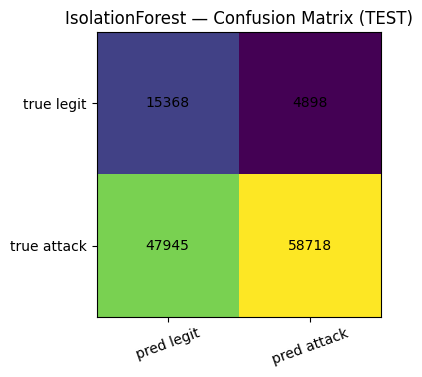

,class,support,anomaly_rate
0,bruteforce,22030,0.211666
1,dos,19392,0.428579
2,flood,17367,0.990730
3,legitimate,20266,0.241686
4,malformed,21732,0.803792
5,slowite,26142,0.423457


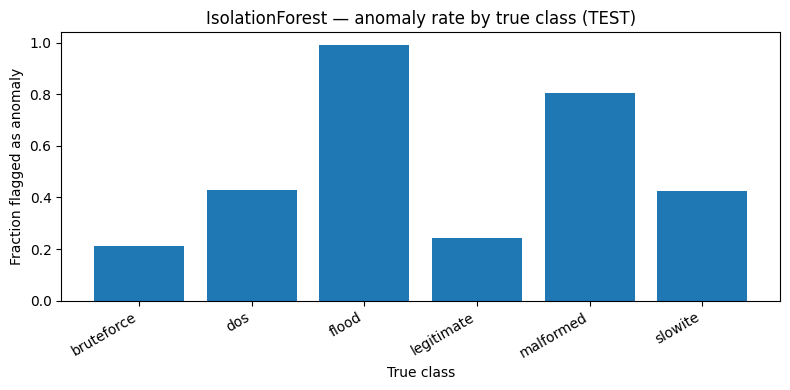

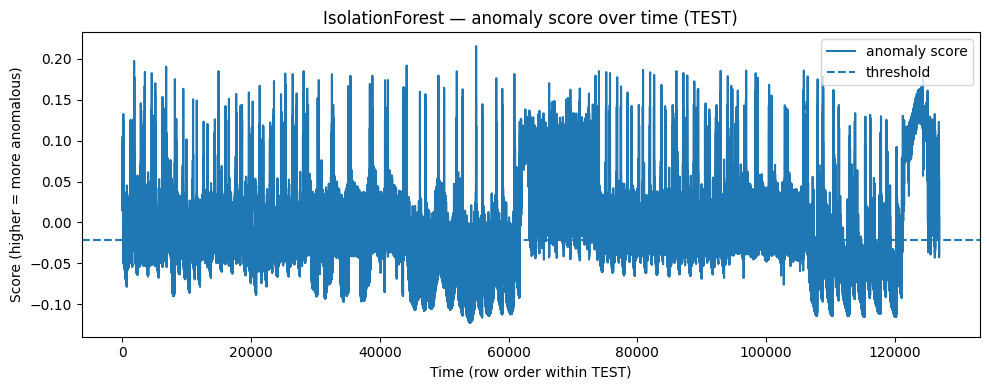

,global_row,score,pred_anomaly,true_bin,true_class
54963,562675,0.215458,1,0,legitimate
1810,509522,0.197462,1,0,legitimate
44165,551877,0.191881,1,0,legitimate
6789,514501,0.190362,1,1,slowite
80905,588617,0.186448,1,1,dos
105899,613611,0.185636,1,1,malformed
96933,604645,0.185636,1,1,malformed
92963,600675,0.185288,1,1,slowite
74053,581765,0.185041,1,1,dos
86088,593800,0.185041,1,1,slowite


In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import IsolationForest
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score, average_precision_score, confusion_matrix

# ---- sanity targets ----
if "target_bin" not in df.columns:
    LEGIT_ID = 3
    df["target_bin"] = (df["Target"].astype(int) != LEGIT_ID).astype(int)

y_bin = df["target_bin"].astype(int).values
y_multi = df["Target"].astype(int).values

X = df.select_dtypes(include="number").drop(columns=["Target", "target_bin"], errors="ignore")

# ---- time-aware split ----
n = len(df)
i_train = int(0.70 * n)
i_val   = int(0.80 * n)

X_train_raw, y_train_bin, y_train_multi = X.iloc[:i_train], y_bin[:i_train], y_multi[:i_train]
X_val_raw,   y_val_bin,   y_val_multi   = X.iloc[i_train:i_val], y_bin[i_train:i_val], y_multi[i_train:i_val]
X_test_raw,  y_test_bin,  y_test_multi  = X.iloc[i_val:], y_bin[i_val:], y_multi[i_val:]

# ---- train only on legitimate rows (unsupervised anomaly training) ----
LEGIT_MASK_TRAIN = (y_train_bin == 0)
X_train_legit = X_train_raw.loc[LEGIT_MASK_TRAIN]

# ---- preprocess (fit on train-legitimate only to avoid leakage) ----
imputer = SimpleImputer(strategy="median")
scaler  = StandardScaler()

X_train_legit_p = scaler.fit_transform(imputer.fit_transform(X_train_legit))
X_val_p  = scaler.transform(imputer.transform(X_val_raw))
X_test_p = scaler.transform(imputer.transform(X_test_raw))

# ---- Isolation Forest ----
iso = IsolationForest(
    n_estimators=400,
    max_samples="auto",
    contamination="auto",
    random_state=42,
    n_jobs=-1
)
iso.fit(X_train_legit_p)

# score: higher = more anomalous (we flip sign)
val_score  = -iso.decision_function(X_val_p)
test_score = -iso.decision_function(X_test_p)

# ---- choose threshold on VAL to maximize F1 (binary) ----
# search thresholds over percentiles (fast + stable)
pct_grid = np.linspace(50, 99.9, 200)
thr_grid = np.percentile(val_score, pct_grid)

best = {"thr": None, "f1": -1, "p": None, "r": None}
for thr in thr_grid:
    pred = (val_score >= thr).astype(int)  # 1=anomaly (attack)
    f1 = f1_score(y_val_bin, pred, zero_division=0)
    if f1 > best["f1"]:
        best.update({
            "thr": float(thr),
            "f1": float(f1),
            "p": float(precision_score(y_val_bin, pred, zero_division=0)),
            "r": float(recall_score(y_val_bin, pred, zero_division=0)),
        })

thr = best["thr"]
print("Chosen threshold (from VAL):", thr)
print("VAL  Precision/Recall/F1:", best["p"], best["r"], best["f1"])
print("VAL  ROC-AUC:", roc_auc_score(y_val_bin, val_score))
print("VAL  PR-AUC :", average_precision_score(y_val_bin, val_score))

# ---- TEST metrics ----
test_pred = (test_score >= thr).astype(int)

print("\nTEST Precision:", precision_score(y_test_bin, test_pred, zero_division=0))
print("TEST Recall:   ", recall_score(y_test_bin, test_pred, zero_division=0))
print("TEST F1:       ", f1_score(y_test_bin, test_pred, zero_division=0))
print("TEST ROC-AUC:  ", roc_auc_score(y_test_bin, test_score))
print("TEST PR-AUC:   ", average_precision_score(y_test_bin, test_score))

# Confusion matrix
cm = confusion_matrix(y_test_bin, test_pred, labels=[0,1])
plt.figure(figsize=(4,4))
plt.imshow(cm)
plt.title("IsolationForest — Confusion Matrix (TEST)")
plt.xticks([0,1], ["pred legit","pred attack"], rotation=20)
plt.yticks([0,1], ["true legit","true attack"])
for (i,j), v in np.ndenumerate(cm):
    plt.text(j, i, str(v), ha="center", va="center")
plt.tight_layout()
plt.show()

# ---- Per-class detection rates (includes legitimate) ----
# For each class, report "anomaly rate" = P(pred=attack | true=class)
LABEL2ID = {"bruteforce": 0, "dos": 1, "flood": 2, "legitimate": 3, "malformed": 4, "slowite": 5}
ID2LABEL = {v: k for k, v in LABEL2ID.items()}

rows = []
for cid in range(6):
    mask = (y_test_multi == cid)
    if mask.sum() == 0:
        continue
    anomaly_rate = float(test_pred[mask].mean())
    rows.append({"class": ID2LABEL[cid], "support": int(mask.sum()), "anomaly_rate": anomaly_rate})

per_class = pd.DataFrame(rows).sort_values("class")
display(per_class)

plt.figure(figsize=(8,4))
plt.bar(per_class["class"], per_class["anomaly_rate"])
plt.title("IsolationForest — anomaly rate by true class (TEST)")
plt.xlabel("True class")
plt.ylabel("Fraction flagged as anomaly")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

# ---- Visualize anomalies over time (TEST only) ----
t = np.arange(len(test_score))
plt.figure(figsize=(10,4))
plt.plot(t, test_score, label="anomaly score")
plt.axhline(thr, linestyle="--", label="threshold")
plt.title("IsolationForest — anomaly score over time (TEST)")
plt.xlabel("Time (row order within TEST)")
plt.ylabel("Score (higher = more anomalous)")
plt.legend()
plt.tight_layout()
plt.show()

# ---- Print detected anomalies (top N in TEST) ----
N = 30
test_idx_global = np.arange(i_val, n)  # map test rows to original df row index positions
out = pd.DataFrame({
    "global_row": test_idx_global,
    "score": test_score,
    "pred_anomaly": test_pred,
    "true_bin": y_test_bin,
    "true_class": [ID2LABEL[c] for c in y_test_multi],
})
anoms = out[out["pred_anomaly"] == 1].sort_values("score", ascending=False).head(N)
display(anoms)


### Cell 10 — Fault injection & noise robustness (XGBoost multiclass)

This cell implements the “fault injection” requirement and measures how stable the multiclass detector is under imperfect IoT conditions.

* **Fault types simulated (2 required)**

  1. **Random feature corruption**: add Gaussian noise to a fraction of numeric values (0%, 10%, 30%).
  2. **Out-of-distribution benign samples**: generate synthetic *legitimate* points (SMOTE-like interpolation) and append them to TEST to simulate “new device behavior”.

* **Leakage-safe preprocessing**
  We fit imputation + scaling on **TRAIN only**, then apply to val/test. Noise is applied after scaling so the magnitude is consistent across features.

* **Retrain per fault level**
  For each fault level, we retrain XGBoost from scratch (same time-aware split) so we can see performance under the new conditions, not just degraded inference.

* **Metrics required by the assignment**

  * **Overall multiclass**: macro precision/recall/F1 + weighted F1
  * **FP% / FN% changes**: computed by collapsing multiclass into `legitimate` vs `attack` and extracting FP and FN rates
  * **Per-attack breakdown**: per-class precision/recall/F1 table (includes legitimate)

* **Stability under noise**
  We measure **prediction agreement vs baseline (0% fault)** on the original TEST set (excluding synthetic additions).
  This gives a direct “how much does the model’s decision change when inputs are noisy” signal.

* **Plots**

  * **F1 vs fault level**: overall robustness trend
  * **FP/FN rate vs fault level**: shows whether noise increases false alarms (FP) or missed attacks (FN)
  * **Per-class F1 vs fault level**: identifies which attack types degrade fastest

* **Example failure cases**
  We list a sample of **label flips** between baseline and the worst fault level to make the robustness issues concrete.


Splits: (444248, 19) (63464, 19) (126929, 19)


,fault_level,noise_cell_frac,synthetic_legit_added,macro_precision,macro_recall,macro_f1,weighted_f1,FP_rate_attack_detection,FN_rate_attack_detection,stability_pred_agreement_vs_baseline
0,0.0,0.0,0,0.882138,0.878651,0.879153,0.877969,0.152423,0.055052,1.000000
1,0.1,0.1,12692,0.885221,0.881427,0.883019,0.878532,0.135445,0.051152,0.949972
2,0.3,0.3,38078,0.868623,0.877235,0.872503,0.874101,0.132302,0.047223,0.923114


,fault_level,class,precision,recall,f1,support
0,0.0,bruteforce,0.869382,0.806990,0.837025,22030.0
1,0.0,dos,0.801044,0.870359,0.834264,19392.0
2,0.0,flood,0.996643,0.940347,0.967677,17367.0
3,0.0,legitimate,0.745238,0.847577,0.793120,20266.0
4,0.0,malformed,0.977934,0.942159,0.959713,21732.0
5,0.0,slowite,0.902588,0.864471,0.883118,26142.0
6,0.1,bruteforce,0.837708,0.809759,0.823497,22030.0
7,0.1,dos,0.798123,0.850557,0.823506,19392.0
8,0.1,flood,0.983484,0.953187,0.968098,17367.0
9,0.1,legitimate,0.839293,0.864555,0.851737,32958.0


,fault_level,macro_f1,Δ_macro_f1,FP_rate_attack_detection,Δ_FP_rate,FN_rate_attack_detection,Δ_FN_rate,stability_pred_agreement_vs_baseline,synthetic_legit_added
0,0.0,0.879153,0.000000,0.152423,0.000000,0.055052,0.000000,1.000000,0
1,0.1,0.883019,0.003866,0.135445,-0.016978,0.051152,-0.003900,0.949972,12692
2,0.3,0.872503,-0.006650,0.132302,-0.020121,0.047223,-0.007828,0.923114,38078


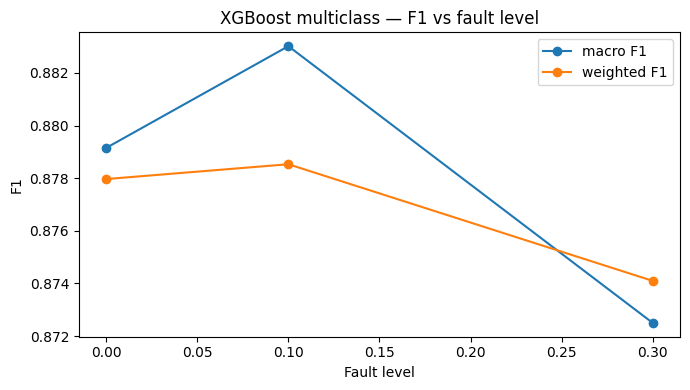

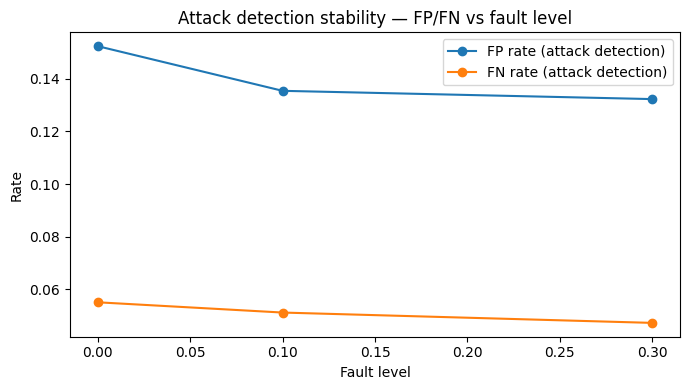

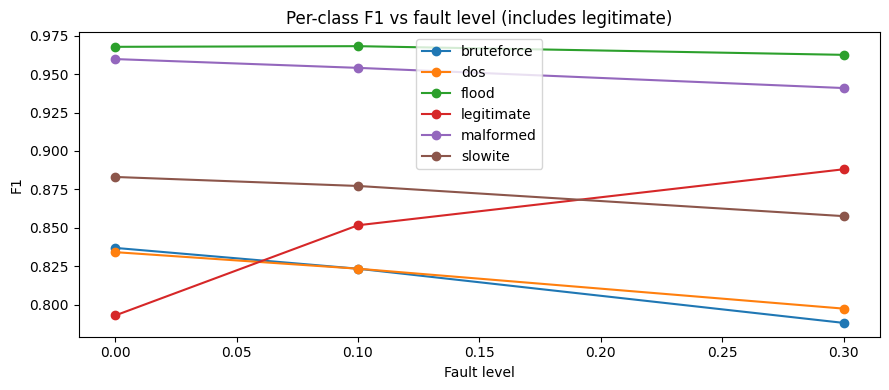

Label flips on original TEST from baseline to fault=0.3: 9970 / 126929 (7.85%)


,test_row_in_split,true,pred_baseline,pred_fault
0,85,legitimate,legitimate,slowite
1,120,slowite,legitimate,slowite
2,132,legitimate,dos,legitimate
3,173,slowite,slowite,dos
4,177,slowite,slowite,dos
5,210,slowite,slowite,malformed
6,218,slowite,slowite,dos
7,222,slowite,slowite,dos
8,229,slowite,slowite,dos
9,230,slowite,slowite,bruteforce


In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import inspect
import xgboost as xgb

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix
)

# ----------------------------
# Config
# ----------------------------
FAULT_LEVELS = [0.0, 0.10, 0.30]     # baseline, 10%, 30%
NOISE_STD = 0.30                    # noise magnitude in standardized space
SYN_BENIGN_FRAC = {0.0: 0.0, 0.10: 0.10, 0.30: 0.30}  # append this fraction of test size as synthetic legit
RNG_SEED = 42

LABEL2ID = {"bruteforce": 0, "dos": 1, "flood": 2, "legitimate": 3, "malformed": 4, "slowite": 5}
ID2LABEL = {v: k for k, v in LABEL2ID.items()}
CLASS_IDS = list(range(6))
CLASS_NAMES = [ID2LABEL[i] for i in CLASS_IDS]
LEGIT_ID = LABEL2ID["legitimate"]

# ----------------------------
# Helpers
# ----------------------------
def gaussian_corrupt(X, level, rng, noise_std=0.3):
    """Corrupt ~level fraction of numeric cells with N(0, noise_std) noise (X is ndarray)."""
    if level <= 0:
        return X
    Xc = X.copy()
    mask = rng.random(Xc.shape) < level
    noise = rng.normal(0.0, noise_std, size=Xc.shape)
    Xc[mask] += noise[mask]
    return Xc

def smote_like_generate(X_legit, n_new, rng):
    """
    SMOTE-like: random linear interpolation between pairs of legitimate samples.
    Works even if you can't/don't want to use imblearn.
    """
    if n_new <= 0:
        return np.empty((0, X_legit.shape[1]), dtype=np.float32)
    if len(X_legit) < 2:
        raise ValueError("Need at least 2 legitimate samples to generate synthetic benign.")
    i1 = rng.integers(0, len(X_legit), size=n_new)
    i2 = rng.integers(0, len(X_legit), size=n_new)
    lam = rng.random(n_new).reshape(-1, 1)
    X_syn = X_legit[i1] + lam * (X_legit[i2] - X_legit[i1])
    return X_syn.astype(np.float32)

def attack_binary_from_multiclass(y_mc):
    """Binary: 0 if legitimate else 1."""
    return (y_mc != LEGIT_ID).astype(int)

def fp_fn_rates_attack_detection(y_true_mc, y_pred_mc):
    """
    FP% and FN% for attack detection derived from multiclass:
    - positive = attack (any non-legitimate)
    - negative = legitimate
    """
    y_true = attack_binary_from_multiclass(y_true_mc)
    y_pred = attack_binary_from_multiclass(y_pred_mc)

    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0,1]).ravel()
    fp_rate = fp / (fp + tn) if (fp + tn) > 0 else 0.0
    fn_rate = fn / (fn + tp) if (fn + tp) > 0 else 0.0
    return fp_rate, fn_rate

def train_xgb_multiclass(Xtr, ytr, Xva, yva, sample_weight=None):
    """Version-tolerant early stopping: callbacks if supported, else constructor param if supported."""
    fit_sig = inspect.signature(xgb.XGBClassifier.fit)
    init_sig = inspect.signature(xgb.XGBClassifier)

    use_callbacks = "callbacks" in fit_sig.parameters
    early_in_init = "early_stopping_rounds" in init_sig.parameters
    early_in_fit  = "early_stopping_rounds" in fit_sig.parameters

    kwargs_init = dict(
        n_estimators=1500,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        objective="multi:softprob",
        num_class=6,
        eval_metric="mlogloss",
        random_state=42,
        tree_method="hist",
    )

    # prefer constructor early stopping if available
    if early_in_init:
        kwargs_init["early_stopping_rounds"] = 50

    clf = xgb.XGBClassifier(**kwargs_init)

    fit_kwargs = dict(
        eval_set=[(Xtr, ytr), (Xva, yva)],
        verbose=False,
    )
    if sample_weight is not None:
        fit_kwargs["sample_weight"] = sample_weight

    if use_callbacks:
        fit_kwargs["callbacks"] = [xgb.callback.EarlyStopping(rounds=50)]
    elif early_in_fit and not early_in_init:
        fit_kwargs["early_stopping_rounds"] = 50

    clf.fit(Xtr, ytr, **fit_kwargs)

    best_iter = getattr(clf, "best_iteration", None)
    if best_iter is None:
        # fallback: use full model
        best_iter = clf.n_estimators - 1
    return clf, int(best_iter)

# ----------------------------
# Prepare base data (time-aware split)
# ----------------------------
y_mc = df["Target"].astype(int).values
X_df = df.select_dtypes(include="number").drop(columns=["Target", "target_bin"], errors="ignore")

n = len(df)
i_train = int(0.70 * n)
i_val   = int(0.80 * n)

X_train_raw = X_df.iloc[:i_train].copy()
y_train_mc  = y_mc[:i_train].copy()

X_val_raw = X_df.iloc[i_train:i_val].copy()
y_val_mc  = y_mc[i_train:i_val].copy()

X_test_raw = X_df.iloc[i_val:].copy()
y_test_mc  = y_mc[i_val:].copy()

print("Splits:", X_train_raw.shape, X_val_raw.shape, X_test_raw.shape)

# Preprocess (fit on TRAIN only)
imputer = SimpleImputer(strategy="median")
scaler  = StandardScaler()

X_train_imp = imputer.fit_transform(X_train_raw)
X_val_imp   = imputer.transform(X_val_raw)
X_test_imp  = imputer.transform(X_test_raw)

X_train_sc = scaler.fit_transform(X_train_imp).astype(np.float32)
X_val_sc   = scaler.transform(X_val_imp).astype(np.float32)
X_test_sc  = scaler.transform(X_test_imp).astype(np.float32)

# Class weights for training (helps imbalance)
present = np.unique(y_train_mc)
cw = compute_class_weight(class_weight="balanced", classes=present, y=y_train_mc)
cw_map = dict(zip(present, cw))
w_train = np.array([cw_map[c] for c in y_train_mc], dtype=np.float32)

# Legitimate pool for synthetic benign generation (use TRAIN legitimate only)
train_legit_mask = (y_train_mc == LEGIT_ID)
X_train_legit_sc = X_train_sc[train_legit_mask]

# ----------------------------
# Run experiments
# ----------------------------
rng_master = np.random.default_rng(RNG_SEED)

summary_rows = []
per_class_rows = []
baseline_test_pred = None  # for stability comparison on original test rows only

for level in FAULT_LEVELS:
    rng = np.random.default_rng(rng_master.integers(0, 1_000_000))

    # Fault Type 1: Gaussian corruption on TRAIN/VAL/TEST
    Xtr = gaussian_corrupt(X_train_sc, level, rng, noise_std=NOISE_STD)
    Xva = gaussian_corrupt(X_val_sc,   level, rng, noise_std=NOISE_STD)
    Xte_base = gaussian_corrupt(X_test_sc,  level, rng, noise_std=NOISE_STD)

    # Fault Type 4: OOD benign via SMOTE-like generation appended to TEST
    n_syn = int(SYN_BENIGN_FRAC[level] * len(Xte_base))
    X_syn = smote_like_generate(X_train_legit_sc, n_syn, rng) if n_syn > 0 else np.empty((0, Xte_base.shape[1]), dtype=np.float32)
    y_syn = np.full(n_syn, LEGIT_ID, dtype=int)

    Xte = np.vstack([Xte_base, X_syn]).astype(np.float32)
    yte = np.concatenate([y_test_mc, y_syn]).astype(int)

    # Train model (retrain each level)
    clf, best_iter = train_xgb_multiclass(Xtr, y_train_mc, Xva, y_val_mc, sample_weight=w_train)

    # Predict (use booster with best_iter if possible; otherwise clf.predict)
    booster = clf.get_booster()
    try:
        p_test = booster.predict(xgb.DMatrix(Xte), iteration_range=(0, best_iter + 1))
    except TypeError:
        p_test = booster.predict(xgb.DMatrix(Xte), ntree_limit=best_iter + 1)

    y_pred = np.argmax(p_test, axis=1)

    # Overall multiclass metrics (macro + weighted)
    prec_macro, rec_macro, f1_macro, _ = precision_recall_fscore_support(
        yte, y_pred, average="macro", zero_division=0
    )
    prec_w, rec_w, f1_w, _ = precision_recall_fscore_support(
        yte, y_pred, average="weighted", zero_division=0
    )

    # Attack-detection FP/FN rates (derived from multiclass)
    fp_rate, fn_rate = fp_fn_rates_attack_detection(yte, y_pred)

    # Stability vs baseline on ORIGINAL TEST rows only (exclude synthetic additions)
    if level == 0.0:
        baseline_test_pred = y_pred[:len(y_test_mc)].copy()
        stability = 1.0
    else:
        cur_pred_base = y_pred[:len(y_test_mc)]
        stability = float((cur_pred_base == baseline_test_pred).mean())

    # Per-class breakdown (includes legitimate)
    rep = classification_report(
        yte, y_pred, labels=CLASS_IDS, target_names=CLASS_NAMES, output_dict=True, zero_division=0
    )
    for cname in CLASS_NAMES:
        per_class_rows.append({
            "fault_level": level,
            "class": cname,
            "precision": rep[cname]["precision"],
            "recall": rep[cname]["recall"],
            "f1": rep[cname]["f1-score"],
            "support": rep[cname]["support"],
        })

    summary_rows.append({
        "fault_level": level,
        "noise_cell_frac": level,
        "synthetic_legit_added": n_syn,
        "macro_precision": prec_macro,
        "macro_recall": rec_macro,
        "macro_f1": f1_macro,
        "weighted_f1": f1_w,
        "FP_rate_attack_detection": fp_rate,
        "FN_rate_attack_detection": fn_rate,
        "stability_pred_agreement_vs_baseline": stability
    })

summary = pd.DataFrame(summary_rows).sort_values("fault_level")
per_class = pd.DataFrame(per_class_rows).sort_values(["fault_level", "class"])

display(summary)
display(per_class)

# ----------------------------
# Compute changes vs baseline (FP% / FN% / F1)
# ----------------------------
base = summary[summary["fault_level"] == 0.0].iloc[0]

summary["Δ_macro_f1"] = summary["macro_f1"] - base["macro_f1"]
summary["Δ_FP_rate"]  = summary["FP_rate_attack_detection"] - base["FP_rate_attack_detection"]
summary["Δ_FN_rate"]  = summary["FN_rate_attack_detection"] - base["FN_rate_attack_detection"]

display(summary[[
    "fault_level", "macro_f1", "Δ_macro_f1",
    "FP_rate_attack_detection", "Δ_FP_rate",
    "FN_rate_attack_detection", "Δ_FN_rate",
    "stability_pred_agreement_vs_baseline",
    "synthetic_legit_added"
]])

# ----------------------------
# Plots: overall robustness + per-class breakdown
# ----------------------------
levels = summary["fault_level"].values

plt.figure(figsize=(7,4))
plt.plot(levels, summary["macro_f1"].values, marker="o", label="macro F1")
plt.plot(levels, summary["weighted_f1"].values, marker="o", label="weighted F1")
plt.title("XGBoost multiclass — F1 vs fault level")
plt.xlabel("Fault level")
plt.ylabel("F1")
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(7,4))
plt.plot(levels, summary["FP_rate_attack_detection"].values, marker="o", label="FP rate (attack detection)")
plt.plot(levels, summary["FN_rate_attack_detection"].values, marker="o", label="FN rate (attack detection)")
plt.title("Attack detection stability — FP/FN vs fault level")
plt.xlabel("Fault level")
plt.ylabel("Rate")
plt.legend()
plt.tight_layout()
plt.show()

# Per-class F1 vs fault level (includes legitimate)
plt.figure(figsize=(9,4))
for cname in CLASS_NAMES:
    s = per_class[per_class["class"] == cname].sort_values("fault_level")
    plt.plot(s["fault_level"].values, s["f1"].values, marker="o", label=cname)
plt.title("Per-class F1 vs fault level (includes legitimate)")
plt.xlabel("Fault level")
plt.ylabel("F1")
plt.legend()
plt.tight_layout()
plt.show()

# ----------------------------
# "Print/visualize detected issues": show biggest label flips from baseline on TEST
# ----------------------------
if len(FAULT_LEVELS) > 1:
    # Compare baseline (0%) vs worst (max fault) on original test only
    worst_level = max(FAULT_LEVELS)
    # Rebuild worst predictions on original test only (no synthetic) for flip listing
    # (Re-run minimal for worst level using already computed per_class? easiest: recompute quickly)

    rng = np.random.default_rng(RNG_SEED + 999)
    Xte_worst = gaussian_corrupt(X_test_sc, worst_level, rng, noise_std=NOISE_STD)

    # retrain worst model quickly using same routine
    Xtr_w = gaussian_corrupt(X_train_sc, worst_level, rng, noise_std=NOISE_STD)
    Xva_w = gaussian_corrupt(X_val_sc,   worst_level, rng, noise_std=NOISE_STD)
    clf_w, best_iter_w = train_xgb_multiclass(Xtr_w, y_train_mc, Xva_w, y_val_mc, sample_weight=w_train)
    booster_w = clf_w.get_booster()
    try:
        p_w = booster_w.predict(xgb.DMatrix(Xte_worst), iteration_range=(0, best_iter_w + 1))
    except TypeError:
        p_w = booster_w.predict(xgb.DMatrix(Xte_worst), ntree_limit=best_iter_w + 1)
    pred_w = np.argmax(p_w, axis=1)

    flips = np.where(pred_w != baseline_test_pred)[0]
    print(f"Label flips on original TEST from baseline to fault={worst_level}: {len(flips)} / {len(y_test_mc)} "
          f"({len(flips)/len(y_test_mc):.2%})")

    # show a few examples
    show_n = 20
    flip_df = pd.DataFrame({
        "test_row_in_split": flips[:show_n],
        "true": [ID2LABEL[c] for c in y_test_mc[flips[:show_n]]],
        "pred_baseline": [ID2LABEL[c] for c in baseline_test_pred[flips[:show_n]]],
        "pred_fault": [ID2LABEL[c] for c in pred_w[flips[:show_n]]],
    })
    display(flip_df)


### Cell 11 — Explainability: feature importance + “which attacks are easier/harder”

This cell covers the required **feature importance / explainability** section for the tree-based model (XGBoost).

* **Reuse the trained multiclass model**
  We locate the already trained multiclass XGBoost model from the notebook variables to avoid retraining.

* **Time-aware TEST evaluation**
  We predict on the final 20% (TEST split), using `best_iteration` when available so results match the early-stopped model.

* **Which attacks are easier/harder?**
  We compute a per-class report (precision/recall/F1/support) and sort by **F1**:

  * “Easiest” = highest per-class F1
  * “Hardest” = lowest per-class F1
    We also plot per-class **F1** and **recall** to quickly see which classes are consistently missed.

* **Which features contribute most to detecting attacks?**
  We extract XGBoost’s built-in feature importance using **gain**:

  * Gain reflects how much a feature improves splits across trees.
  * We show the **top-K** features and plot them as a bar chart.

* **More reliable check (permutation importance)**
  Built-in importance can be biased, so we optionally validate it via **permutation importance**:

  * Shuffle one feature at a time on a TEST sample
  * Measure how much **macro-F1 drops**
  * Bigger drop ⇒ feature is more important for performance

Output: a clear mapping from (a) **top features** and (b) **per-attack difficulty**, both backed by tables + plots.


,precision,recall,f1,support
flood,0.996610,0.947832,0.971609,17367.0
malformed,0.978007,0.943309,0.960345,21732.0
slowite,0.900989,0.864318,0.882273,26142.0
bruteforce,0.869427,0.808216,0.837705,22030.0
dos,0.800513,0.868709,0.833218,19392.0
legitimate,0.751247,0.847034,0.796271,20266.0



Easiest classes (highest F1):


,precision,recall,f1,support
flood,0.996610,0.947832,0.971609,17367.0
malformed,0.978007,0.943309,0.960345,21732.0
slowite,0.900989,0.864318,0.882273,26142.0



Hardest classes (lowest F1):


,precision,recall,f1,support
bruteforce,0.869427,0.808216,0.837705,22030.0
dos,0.800513,0.868709,0.833218,19392.0
legitimate,0.751247,0.847034,0.796271,20266.0


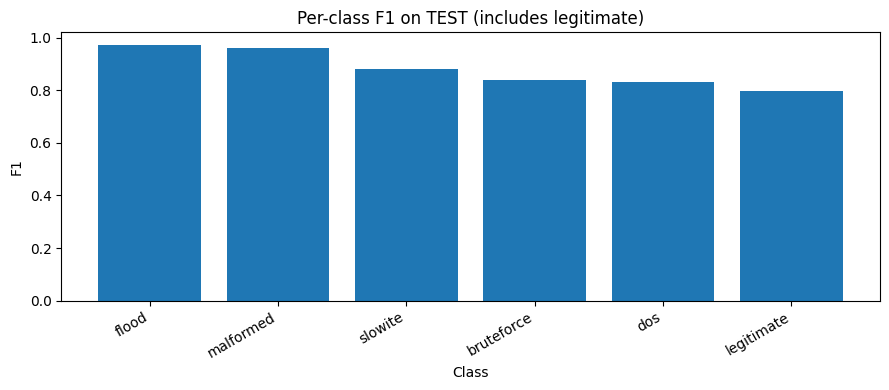

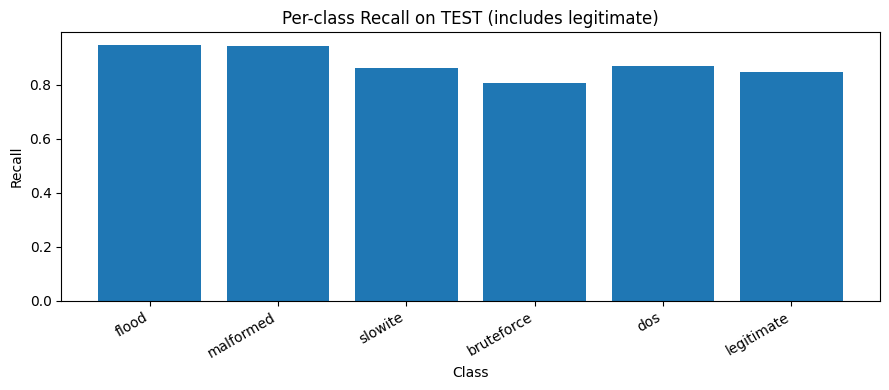

,gain_importance
mqtt_qos,80.314011
payload_len_roll_mean_10s,52.383224
mqtt_hdrflags,47.469448
tcp_len,43.815090
mqtt_msg,34.170517
msg_rate_10s,30.206879
msg_rate_1s,28.694948
payload_len,25.136229
payload_len_roll_std_10s,22.550615
iat_s,19.707281


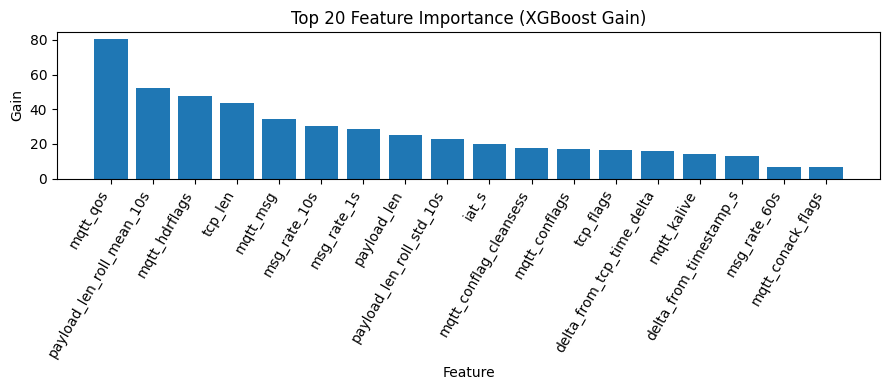

,macro_F1_drop
payload_len_roll_mean_10s,0.273882
msg_rate_1s,0.173918
payload_len_roll_std_10s,0.145292
msg_rate_10s,0.124315
tcp_len,0.055370
msg_rate_60s,0.053724
mqtt_qos,0.024744
mqtt_msg,0.011776
delta_from_timestamp_s,0.007186
delta_from_tcp_time_delta,0.006681


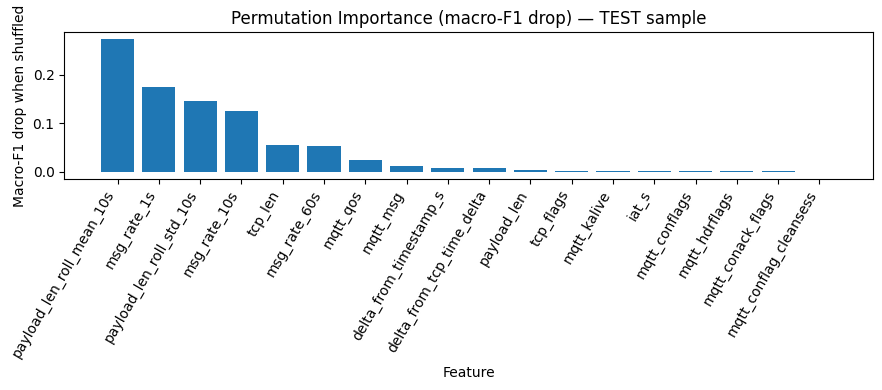

In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import xgboost as xgb

from sklearn.metrics import classification_report, f1_score

# -----------------------------
# Pick the trained multiclass model from globals()
# -----------------------------
# Change this if your model variable has a different name.
model = None
for name in ["clf_multi", "clf", "xgb_model", "model_multi"]:
    if name in globals():
        model = globals()[name]
        break

if model is None:
    raise NameError("Couldn't find a trained XGBoost model in variables (expected clf_multi / clf / xgb_model / model_multi).")

# -----------------------------
# Data + time-aware split (must match how you trained)
# -----------------------------
LABEL2ID = {"bruteforce": 0, "dos": 1, "flood": 2, "legitimate": 3, "malformed": 4, "slowite": 5}
ID2LABEL = {v: k for k, v in LABEL2ID.items()}
CLASS_IDS = list(range(6))
CLASS_NAMES = [ID2LABEL[i] for i in CLASS_IDS]

y = df["Target"].astype(int).values
X = df.select_dtypes(include="number").drop(columns=["Target", "target_bin"], errors="ignore")

n = len(df)
i_train = int(0.70 * n)
i_val   = int(0.80 * n)

X_test = X.iloc[i_val:].copy()
y_test = y[i_val:].copy()

# -----------------------------
# Predict on TEST using best_iteration if available
# -----------------------------
best_iter = getattr(model, "best_iteration", None)
booster = model.get_booster()

dtest = xgb.DMatrix(X_test)
try:
    if best_iter is not None:
        proba = booster.predict(dtest, iteration_range=(0, best_iter + 1))
    else:
        proba = booster.predict(dtest)
except TypeError:
    # older API fallback
    ntree = (best_iter + 1) if best_iter is not None else 0
    proba = booster.predict(dtest, ntree_limit=ntree)

y_pred = np.argmax(proba, axis=1)

# -----------------------------
# Q2: Which attacks are easier/harder? -> per-class metrics on TEST
# -----------------------------
rep = classification_report(
    y_test, y_pred,
    labels=CLASS_IDS,
    target_names=CLASS_NAMES,
    output_dict=True,
    zero_division=0
)

per_class = pd.DataFrame({k: rep[k] for k in CLASS_NAMES}).T[["precision", "recall", "f1-score", "support"]]
per_class = per_class.rename(columns={"f1-score": "f1"}).sort_values("f1", ascending=False)
display(per_class)

print("\nEasiest classes (highest F1):")
display(per_class.head(3))

print("\nHardest classes (lowest F1):")
display(per_class.tail(3))

plt.figure(figsize=(9,4))
plt.bar(per_class.index, per_class["f1"].values)
plt.title("Per-class F1 on TEST (includes legitimate)")
plt.xlabel("Class")
plt.ylabel("F1")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

plt.figure(figsize=(9,4))
plt.bar(per_class.index, per_class["recall"].values)
plt.title("Per-class Recall on TEST (includes legitimate)")
plt.xlabel("Class")
plt.ylabel("Recall")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

# -----------------------------
# Q1: Which features contribute most? -> XGBoost gain importance
# -----------------------------
gain = booster.get_score(importance_type="gain")  # dict

# Map f0,f1,... -> column names if needed
def map_feature_name(k):
    if k.startswith("f") and k[1:].isdigit():
        idx = int(k[1:])
        if idx < len(X.columns):
            return X.columns[idx]
    return k

gain_s = pd.Series({map_feature_name(k): v for k, v in gain.items()}).sort_values(ascending=False)

TOPK = 20
top_gain = gain_s.head(TOPK)
display(top_gain.to_frame("gain_importance"))

plt.figure(figsize=(9,4))
plt.bar(top_gain.index, top_gain.values)
plt.title(f"Top {TOPK} Feature Importance (XGBoost Gain)")
plt.xlabel("Feature")
plt.ylabel("Gain")
plt.xticks(rotation=60, ha="right")
plt.tight_layout()
plt.show()

# -----------------------------
# Optional: permutation importance (more reliable) on a sample of TEST
# Measures macro-F1 drop when you shuffle one feature.
# -----------------------------
DO_PERMUTATION = True
SAMPLE_N = min(8000, len(X_test))
rng = np.random.default_rng(42)

if DO_PERMUTATION:
    idx = rng.choice(len(X_test), size=SAMPLE_N, replace=False)
    Xs = X_test.iloc[idx].copy()
    ys = y_test[idx].copy()

    # baseline macro-F1
    ds = xgb.DMatrix(Xs)
    try:
        if best_iter is not None:
            p0 = booster.predict(ds, iteration_range=(0, best_iter + 1))
        else:
            p0 = booster.predict(ds)
    except TypeError:
        ntree = (best_iter + 1) if best_iter is not None else 0
        p0 = booster.predict(ds, ntree_limit=ntree)

    y0 = np.argmax(p0, axis=1)
    base_macro_f1 = f1_score(ys, y0, average="macro", zero_division=0)

    # only permute top_gain features (fast + meaningful)
    perm_feats = list(top_gain.index)
    drops = []

    for feat in perm_feats:
        Xp = Xs.copy()
        Xp[feat] = rng.permutation(Xp[feat].values)
        dp = xgb.DMatrix(Xp)

        try:
            if best_iter is not None:
                pp = booster.predict(dp, iteration_range=(0, best_iter + 1))
            else:
                pp = booster.predict(dp)
        except TypeError:
            ntree = (best_iter + 1) if best_iter is not None else 0
            pp = booster.predict(dp, ntree_limit=ntree)

        yp = np.argmax(pp, axis=1)
        f1p = f1_score(ys, yp, average="macro", zero_division=0)
        drops.append(base_macro_f1 - f1p)

    perm = pd.Series(drops, index=perm_feats).sort_values(ascending=False)
    display(perm.to_frame("macro_F1_drop"))

    plt.figure(figsize=(9,4))
    plt.bar(perm.index, perm.values)
    plt.title("Permutation Importance (macro-F1 drop) — TEST sample")
    plt.xlabel("Feature")
    plt.ylabel("Macro-F1 drop when shuffled")
    plt.xticks(rotation=60, ha="right")
    plt.tight_layout()
    plt.show()


### Cell 12 — Real-time IDS pipeline (model loading + replay + online feature extraction)

This cell implements the required **detection pipeline** that simulates real-time operation.

* **Load trained model (deployment style)**
  We load the saved `xgb_multiclass.json` booster from disk so the pipeline works independently of the training code.

* **Replay stream from the TEST split**
  We read the processed CSV, parse timestamps, sort in timestamp order, and replay **only the last 20%** (TEST).
  This makes the pipeline evaluation match the “future traffic” scenario.

* **Online feature extraction (stateful)**
  Some features depend on past messages, so we maintain rolling state:

  * `iat_s`: time since previous message
  * `msg_rate_1s / 10s / 60s`: message counts in recent windows
  * rolling payload mean/std (payload proxy via `tcp_len`)
    We reset the rolling windows if a large timestamp gap appears (session boundary).

* **Continuous predictions**
  We batch a few records for efficient inference, but conceptually the model is producing predictions “as messages arrive.”
  Each output record contains:
  `timestamp | features | predicted_label | confidence | true_label`

* **Result inspection + export**
  We show a preview of the streamed output, print a quick mismatch count, and save the full stream to:
  `models/ids_stream_output_test.csv` for submission.


In [14]:
import math
from pathlib import Path
from collections import deque

import numpy as np
import pandas as pd
import xgboost as xgb

# -------------------------
# Load model ONLY
# -------------------------
MODEL_PATH = Path("models/xgb_multiclass.json")
if not MODEL_PATH.exists():
    raise FileNotFoundError("Missing models/xgb_multiclass.json. Save it from the training cell first.")

booster = xgb.Booster()
booster.load_model(MODEL_PATH.as_posix())

best_iter_attr = booster.attr("best_iteration")
best_iter = int(best_iter_attr) if best_iter_attr is not None else None

print("Loaded model:", MODEL_PATH.resolve())
print("best_iter from model:", best_iter)

# -------------------------
# Feature names (derive from CURRENT df like training did)
# Must match what you trained on: numeric columns excluding labels
# -------------------------
feature_names = df.select_dtypes(include="number").drop(columns=["Target", "target_bin"], errors="ignore").columns.tolist()
print("#features:", len(feature_names))

# Label mapping (known)
LABEL2ID = {"bruteforce": 0, "dos": 1, "flood": 2, "legitimate": 3, "malformed": 4, "slowite": 5}
ID2LABEL = {v: k for k, v in LABEL2ID.items()}
LEGIT_ID = LABEL2ID["legitimate"]

# -------------------------
# Load raw data for replay (pick from TEST set)
# -------------------------
csv_path = globals().get("CSV_PATH", Path("Dataset/Preprocessed_Data") / "MQTTEEB-D_dataset_All_Processed.csv")
raw = pd.read_csv(csv_path)

# parse timestamp: "9/9/2024  3:17:54 AM"
ts_clean = raw["timestamp"].astype(str).str.replace(r"\s+", " ", regex=True).str.strip()
ts = pd.to_datetime(ts_clean, errors="coerce", utc=True)

raw = raw[ts.notna()].copy()
raw["_t_epoch"] = (ts[ts.notna()].dt.tz_localize(None).astype("int64") / 1e9).astype("float64")
raw = raw.sort_values("_t_epoch").reset_index(drop=True)

n = len(raw)
i_train = int(0.70 * n)
i_val   = int(0.80 * n)     # TEST starts here
print("Rows:", n, "| Train:", i_train, "Val:", i_val - i_train, "Test:", n - i_val)

# Ensure we can read base numeric values from raw by column name
raw_num_cols = raw.select_dtypes(include="number").columns.tolist()
raw_num_cols = [c for c in raw_num_cols if c not in ["Target", "_t_epoch"]]
col_idx = {c: i for i, c in enumerate(raw_num_cols)}

t_arr = raw["_t_epoch"].to_numpy()
ts_arr = raw["timestamp"].astype(str).to_numpy()
y_true_arr = raw["Target"].astype(int).to_numpy()
base_mat = raw[raw_num_cols].to_numpy(dtype=np.float32)

# -------------------------
# Real-time feature extractor (stateful)
# -------------------------
GAP_RESET_S = 60.0  # loop boundary reset

# We only compute engineered features if the model expects them
need = {
    "iat_s": "iat_s" in feature_names,
    "msg_rate_1s": "msg_rate_1s" in feature_names,
    "msg_rate_10s": "msg_rate_10s" in feature_names,
    "msg_rate_60s": "msg_rate_60s" in feature_names,
    "payload_len": "payload_len" in feature_names,
    "payload_len_roll_mean_10s": "payload_len_roll_mean_10s" in feature_names,
    "payload_len_roll_std_10s": "payload_len_roll_std_10s" in feature_names,
}

q1, q10, q60 = deque(), deque(), deque()
q_payload = deque()   # (t, payload)
sum_p, sumsq_p = 0.0, 0.0
prev_t = None

def reset_windows():
    global sum_p, sumsq_p, prev_t
    q1.clear(); q10.clear(); q60.clear()
    q_payload.clear()
    sum_p = 0.0; sumsq_p = 0.0
    prev_t = None

def update_rates(t):
    q1.append(t); q10.append(t); q60.append(t)
    while q1 and (t - q1[0]) > 1.0:   q1.popleft()
    while q10 and (t - q10[0]) > 10.0: q10.popleft()
    while q60 and (t - q60[0]) > 60.0: q60.popleft()
    return float(len(q1)), float(len(q10)), float(len(q60))

def update_payload_stats(t, payload):
    global sum_p, sumsq_p
    q_payload.append((t, payload))
    sum_p += payload
    sumsq_p += payload * payload
    while q_payload and (t - q_payload[0][0]) > 10.0:
        _, old = q_payload.popleft()
        sum_p -= old
        sumsq_p -= old * old
    n = len(q_payload)
    if n <= 0:
        return 0.0, 0.0
    mean = sum_p / n
    var = max(0.0, (sumsq_p / n) - mean * mean)
    std = math.sqrt(var) if n > 1 else 0.0
    return float(mean), float(std)

def build_feature_vector(t, base_row):
    global prev_t

    if prev_t is not None and (t - prev_t) > GAP_RESET_S:
        reset_windows()

    feats = {}

    if need["iat_s"]:
        feats["iat_s"] = 0.0 if prev_t is None else float(max(0.0, t - prev_t))

    if need["msg_rate_1s"] or need["msg_rate_10s"] or need["msg_rate_60s"]:
        r1, r10, r60 = update_rates(t)
        if need["msg_rate_1s"]:  feats["msg_rate_1s"]  = r1
        if need["msg_rate_10s"]: feats["msg_rate_10s"] = r10
        if need["msg_rate_60s"]: feats["msg_rate_60s"] = r60

    # payload proxy (same as earlier): tcp_len
    payload = float(base_row[col_idx["tcp_len"]]) if "tcp_len" in col_idx else 0.0
    if need["payload_len"]:
        feats["payload_len"] = payload

    if need["payload_len_roll_mean_10s"] or need["payload_len_roll_std_10s"]:
        m, s = update_payload_stats(t, payload)
        if need["payload_len_roll_mean_10s"]: feats["payload_len_roll_mean_10s"] = m
        if need["payload_len_roll_std_10s"]:  feats["payload_len_roll_std_10s"]  = s

    prev_t = t

    # assemble in training column order
    x = np.zeros((len(feature_names),), dtype=np.float32)
    for j, fname in enumerate(feature_names):
        if fname in feats:
            x[j] = np.float32(feats[fname])
        elif fname in col_idx:
            x[j] = np.float32(base_row[col_idx[fname]])
        else:
            x[j] = np.float32(0.0)
    return x

# -------------------------
# Replay TEST only + predict continuously
# -------------------------
BATCH = 512
rows = []
bufX, bufMeta = [], []

for i in range(i_val, n):
    t = float(t_arr[i])
    x_vec = build_feature_vector(t, base_mat[i])

    bufX.append(x_vec)
    bufMeta.append((ts_arr[i], int(y_true_arr[i])))

    if len(bufX) >= BATCH:
        Xb = np.vstack(bufX)
        dm = xgb.DMatrix(Xb, feature_names=feature_names)

        try:
            proba = booster.predict(dm, iteration_range=(0, best_iter + 1)) if best_iter is not None else booster.predict(dm)
        except TypeError:
            proba = booster.predict(dm, ntree_limit=(best_iter + 1) if best_iter is not None else 0)

        pred_id = np.argmax(proba, axis=1)
        conf = np.max(proba, axis=1)

        for k in range(len(bufX)):
            ts_str, y_true = bufMeta[k]
            row = {"timestamp": ts_str}
            for j, fname in enumerate(feature_names):
                row[fname] = float(bufX[k][j])
            row["predicted_label"] = ID2LABEL.get(int(pred_id[k]), str(int(pred_id[k])))
            row["confidence"] = float(conf[k])
            row["true_label"] = ID2LABEL.get(int(y_true), str(int(y_true)))
            rows.append(row)

        bufX.clear()
        bufMeta.clear()

# flush
if bufX:
    Xb = np.vstack(bufX)
    dm = xgb.DMatrix(Xb, feature_names=feature_names)
    try:
        proba = booster.predict(dm, iteration_range=(0, best_iter + 1)) if best_iter is not None else booster.predict(dm)
    except TypeError:
        proba = booster.predict(dm, ntree_limit=(best_iter + 1) if best_iter is not None else 0)

    pred_id = np.argmax(proba, axis=1)
    conf = np.max(proba, axis=1)

    for k in range(len(bufX)):
        ts_str, y_true = bufMeta[k]
        row = {"timestamp": ts_str}
        for j, fname in enumerate(feature_names):
            row[fname] = float(bufX[k][j])
        row["predicted_label"] = ID2LABEL.get(int(pred_id[k]), str(int(pred_id[k])))
        row["confidence"] = float(conf[k])
        row["true_label"] = ID2LABEL.get(int(y_true), str(int(y_true)))
        rows.append(row)

stream_df = pd.DataFrame(rows)
display(stream_df.head(10))

# optional quick view: mismatches
mismatch = stream_df[stream_df["predicted_label"] != stream_df["true_label"]]
print("TEST predicted rows:", len(stream_df))
print("Mismatches:", len(mismatch), f"({len(mismatch)/max(len(stream_df),1):.2%})")
display(mismatch.head(10))

# save
out_path = Path("models") / "ids_stream_output_test.csv"
out_path.parent.mkdir(parents=True, exist_ok=True)
stream_df.to_csv(out_path, index=False)
print("Saved stream output to:", out_path.resolve())


Loaded model: C:\Stuff\facultate\an II Master\IoT\Assignment 3\models\xgb_multiclass.json
best_iter from model: None
#features: 19
Rows: 222813 | Train: 155969 Val: 22281 Test: 44563


,timestamp,tcp_flags,tcp_len,mqtt_conack_flags,mqtt_conflag_cleansess,mqtt_conflags,mqtt_dupflag,mqtt_hdrflags,mqtt_kalive,mqtt_msg,...,iat_s,msg_rate_1s,msg_rate_10s,msg_rate_60s,payload_len,payload_len_roll_mean_10s,payload_len_roll_std_10s,predicted_label,confidence,true_label
0,2024-09-09 14:07:55.966376066,24.0,982.0,0.0,0.0,0.0,0.0,48.0,0.0,0.0,...,0.000000,1.0,1.0,1.0,982.0,982.000000,0.000000,legitimate,0.880500,slowite
1,2024-09-09 14:07:56.470771074,24.0,587.0,0.0,0.0,0.0,0.0,48.0,0.0,0.0,...,0.504395,2.0,2.0,2.0,587.0,784.500000,197.500000,slowite,0.889730,slowite
2,2024-09-09 14:07:56.974844933,24.0,1601.0,0.0,0.0,0.0,0.0,48.0,0.0,0.0,...,0.504074,2.0,3.0,3.0,1601.0,1056.666626,417.317078,slowite,0.877289,slowite
3,2024-09-09 14:07:57.478636980,24.0,1723.0,0.0,0.0,0.0,0.0,48.0,0.0,0.0,...,0.503792,2.0,4.0,4.0,1723.0,1223.250000,462.455597,slowite,0.893279,slowite
4,2024-09-09 14:07:57.982326031,24.0,1441.0,0.0,0.0,0.0,0.0,48.0,0.0,0.0,...,0.503689,2.0,5.0,5.0,1441.0,1266.800049,422.703857,slowite,0.932513,slowite
5,2024-09-09 14:07:58.486291885,24.0,1388.0,0.0,0.0,0.0,0.0,48.0,0.0,0.0,...,0.503966,2.0,6.0,6.0,1388.0,1287.000000,388.508698,slowite,0.948174,slowite
6,2024-09-09 14:07:58.990715027,24.0,950.0,0.0,0.0,0.0,0.0,48.0,0.0,0.0,...,0.504423,2.0,7.0,7.0,950.0,1238.857178,378.527008,slowite,0.979096,slowite
7,2024-09-09 14:07:59.493484020,24.0,1370.0,0.0,0.0,0.0,0.0,48.0,0.0,0.0,...,0.502769,2.0,8.0,8.0,1370.0,1255.250000,356.725983,slowite,0.953799,slowite
8,2024-09-09 14:07:59.998713970,24.0,784.0,0.0,0.0,0.0,0.0,48.0,0.0,0.0,...,0.505230,2.0,9.0,9.0,784.0,1202.888916,367.488312,slowite,0.982523,slowite
9,2024-09-09 14:08:00.498799086,24.0,651.0,0.0,0.0,0.0,0.0,48.0,0.0,0.0,...,0.500085,2.0,10.0,10.0,651.0,1147.699951,385.947174,slowite,0.970718,slowite


TEST predicted rows: 44563
Mismatches: 14258 (32.00%)


,timestamp,tcp_flags,tcp_len,mqtt_conack_flags,mqtt_conflag_cleansess,mqtt_conflags,mqtt_dupflag,mqtt_hdrflags,mqtt_kalive,mqtt_msg,...,iat_s,msg_rate_1s,msg_rate_10s,msg_rate_60s,payload_len,payload_len_roll_mean_10s,payload_len_roll_std_10s,predicted_label,confidence,true_label
0,2024-09-09 14:07:55.966376066,24.0,982.0,0.0,0.0,0.0,0.0,48.0,0.0,0.0,...,0.000000,1.0,1.0,1.0,982.0,982.000000,0.000000,legitimate,0.880500,slowite
10,2024-09-09 14:08:00.718521118,24.0,618.0,0.0,0.0,0.0,0.0,53.0,0.0,40698.0,...,0.219722,3.0,11.0,11.0,618.0,1099.545410,398.249207,legitimate,0.981847,slowite
32,2024-09-09 14:08:11.201647997,24.0,609.0,0.0,0.0,0.0,0.0,53.0,0.0,40698.0,...,0.107716,3.0,21.0,33.0,609.0,1168.428589,391.508881,legitimate,0.994498,slowite
42,2024-09-09 14:08:21.690090895,24.0,614.0,0.0,0.0,0.0,0.0,53.0,0.0,40698.0,...,6.057970,1.0,9.0,43.0,614.0,1073.222168,361.702698,legitimate,0.999345,slowite
43,2024-09-09 14:08:32.171892881,24.0,614.0,0.0,0.0,0.0,0.0,53.0,0.0,40698.0,...,10.481802,1.0,1.0,44.0,614.0,614.000000,0.000000,legitimate,0.999663,slowite
49,2024-09-09 14:09:21.523893118,24.0,39.0,0.0,1.0,130.0,0.0,16.0,60.0,0.0,...,7.408153,1.0,2.0,8.0,39.0,328.000000,289.000000,dos,0.831081,slowite
50,2024-09-09 14:09:21.551495075,24.0,39.0,0.0,1.0,130.0,0.0,16.0,60.0,0.0,...,0.027602,2.0,3.0,9.0,39.0,231.666672,272.471802,dos,0.772651,slowite
51,2024-09-09 14:09:21.558520079,24.0,39.0,0.0,1.0,130.0,0.0,16.0,60.0,0.0,...,0.007025,3.0,4.0,10.0,39.0,183.500000,250.281342,dos,0.766080,slowite
52,2024-09-09 14:09:21.564539909,24.0,39.0,0.0,1.0,130.0,0.0,16.0,60.0,0.0,...,0.006020,4.0,5.0,11.0,39.0,154.600006,231.199997,dos,0.803267,slowite
53,2024-09-09 14:09:21.571824074,24.0,39.0,0.0,1.0,130.0,0.0,16.0,60.0,0.0,...,0.007284,5.0,6.0,12.0,39.0,135.333328,215.407883,dos,0.772917,slowite


Saved stream output to: C:\Stuff\facultate\an II Master\IoT\Assignment 3\models\ids_stream_output_test.csv


In [15]:
# Real-time IDS replay (TEST only) — print each prediction as:
# timestamp | features | predicted_label | confidence | true_label
# Set WAIT_S > 0 to slow it down for readability. If WAIT_S == 0, we run fast and report predictions/sec.

import time, math
from pathlib import Path
from collections import deque

import numpy as np
import pandas as pd
import xgboost as xgb

# -------------------------
# Controls
# -------------------------
WAIT_S = 1          # 0 = run fast; >0 = sleep between printed predictions
BATCH = 256           # batch size for model inference
GAP_RESET_S = 60.0    # reset rolling windows at big gaps

# -------------------------
# Load model only
# -------------------------
MODEL_PATH = Path("models/xgb_multiclass.json")
booster = xgb.Booster()
booster.load_model(MODEL_PATH.as_posix())
best_iter_attr = booster.attr("best_iteration")
best_iter = int(best_iter_attr) if best_iter_attr is not None else None

# Derive training feature order from the current df (must match training)
feature_names = df.select_dtypes(include="number").drop(columns=["Target", "target_bin"], errors="ignore").columns.tolist()

LABEL2ID = {"bruteforce": 0, "dos": 1, "flood": 2, "legitimate": 3, "malformed": 4, "slowite": 5}
ID2LABEL = {v: k for k, v in LABEL2ID.items()}

print("Loaded:", MODEL_PATH)
print("best_iter:", best_iter)
print("#features:", len(feature_names))
print("WAIT_S:", WAIT_S)

# -------------------------
# Load raw dataset + prepare TEST replay order
# -------------------------
csv_path = globals().get("CSV_PATH", Path("Dataset/Preprocessed_Data") / "MQTTEEB-D_dataset_All_Processed.csv")
raw = pd.read_csv(csv_path)

ts_clean = raw["timestamp"].astype(str).str.replace(r"\s+", " ", regex=True).str.strip()
ts = pd.to_datetime(ts_clean, errors="coerce", utc=True)
raw = raw[ts.notna()].copy()
raw["_t_epoch"] = (ts[ts.notna()].dt.tz_localize(None).astype("int64") / 1e9).astype("float64")

raw = raw.sort_values("_t_epoch").reset_index(drop=True)

n = len(raw)
i_train = int(0.70 * n)
i_val   = int(0.80 * n)  # TEST begins here

t_arr = raw["_t_epoch"].to_numpy()
ts_arr = raw["timestamp"].astype(str).to_numpy()
y_true_arr = raw["Target"].astype(int).to_numpy()

raw_num_cols = raw.select_dtypes(include="number").columns.tolist()
raw_num_cols = [c for c in raw_num_cols if c not in ["Target", "_t_epoch"]]
col_idx = {c: i for i, c in enumerate(raw_num_cols)}
base_mat = raw[raw_num_cols].to_numpy(dtype=np.float32)

print("Replay TEST rows:", n - i_val)

# -------------------------
# Real-time feature extractor (stateful)
# -------------------------
need = {
    "iat_s": "iat_s" in feature_names,
    "msg_rate_1s": "msg_rate_1s" in feature_names,
    "msg_rate_10s": "msg_rate_10s" in feature_names,
    "msg_rate_60s": "msg_rate_60s" in feature_names,
    "payload_len": "payload_len" in feature_names,
    "payload_len_roll_mean_10s": "payload_len_roll_mean_10s" in feature_names,
    "payload_len_roll_std_10s": "payload_len_roll_std_10s" in feature_names,
}

q1, q10, q60 = deque(), deque(), deque()
q_payload = deque()    # (t, payload)
sum_p, sumsq_p = 0.0, 0.0
prev_t = None

def reset_windows():
    global sum_p, sumsq_p, prev_t
    q1.clear(); q10.clear(); q60.clear()
    q_payload.clear()
    sum_p = 0.0; sumsq_p = 0.0
    prev_t = None

def update_rates(t):
    q1.append(t); q10.append(t); q60.append(t)
    while q1 and (t - q1[0]) > 1.0:    q1.popleft()
    while q10 and (t - q10[0]) > 10.0: q10.popleft()
    while q60 and (t - q60[0]) > 60.0: q60.popleft()
    return float(len(q1)), float(len(q10)), float(len(q60))

def update_payload_stats(t, payload):
    global sum_p, sumsq_p
    q_payload.append((t, payload))
    sum_p += payload
    sumsq_p += payload * payload
    while q_payload and (t - q_payload[0][0]) > 10.0:
        _, old = q_payload.popleft()
        sum_p -= old
        sumsq_p -= old * old
    n = len(q_payload)
    if n <= 0:
        return 0.0, 0.0
    mean = sum_p / n
    var = max(0.0, (sumsq_p / n) - mean * mean)
    std = math.sqrt(var) if n > 1 else 0.0
    return float(mean), float(std)

def build_feature_vector(t, base_row):
    global prev_t

    if prev_t is not None and (t - prev_t) > GAP_RESET_S:
        reset_windows()

    feats = {}

    # IAT
    if need["iat_s"]:
        feats["iat_s"] = 0.0 if prev_t is None else float(max(0.0, t - prev_t))

    # rates
    if need["msg_rate_1s"] or need["msg_rate_10s"] or need["msg_rate_60s"]:
        r1, r10, r60 = update_rates(t)
        if need["msg_rate_1s"]:  feats["msg_rate_1s"]  = r1
        if need["msg_rate_10s"]: feats["msg_rate_10s"] = r10
        if need["msg_rate_60s"]: feats["msg_rate_60s"] = r60

    # payload proxy
    payload = float(base_row[col_idx["tcp_len"]]) if "tcp_len" in col_idx else 0.0
    if need["payload_len"]:
        feats["payload_len"] = payload

    if need["payload_len_roll_mean_10s"] or need["payload_len_roll_std_10s"]:
        m, s = update_payload_stats(t, payload)
        if need["payload_len_roll_mean_10s"]: feats["payload_len_roll_mean_10s"] = m
        if need["payload_len_roll_std_10s"]:  feats["payload_len_roll_std_10s"]  = s

    prev_t = t

    # Assemble vector in training order
    x = np.zeros((len(feature_names),), dtype=np.float32)
    for j, fname in enumerate(feature_names):
        if fname in feats:
            x[j] = np.float32(feats[fname])
        elif fname in col_idx:
            x[j] = np.float32(base_row[col_idx[fname]])
        else:
            x[j] = np.float32(0.0)
    return x

# Pretty-print helper
def fmt_features(x_vec, max_items=8):
    # show first N features for readability
    items = []
    for i, fname in enumerate(feature_names[:max_items]):
        items.append(f"{fname}={x_vec[i]:.3g}")
    if len(feature_names) > max_items:
        items.append("...")
    return "{" + ", ".join(items) + "}"

# -------------------------
# Replay TEST and print predictions
# -------------------------
def predict_batch(Xb):
    dm = xgb.DMatrix(Xb, feature_names=feature_names)
    try:
        proba = booster.predict(dm, iteration_range=(0, best_iter + 1)) if best_iter is not None else booster.predict(dm)
    except TypeError:
        proba = booster.predict(dm, ntree_limit=(best_iter + 1) if best_iter is not None else 0)
    pred = np.argmax(proba, axis=1)
    conf = np.max(proba, axis=1)
    return pred, conf

bufX, bufMeta = [], []  # meta: (timestamp_str, true_label_id)
printed = 0

t0 = time.perf_counter()

for i in range(i_val, n):
    t = float(t_arr[i])
    x_vec = build_feature_vector(t, base_mat[i])

    bufX.append(x_vec)
    bufMeta.append((ts_arr[i], int(y_true_arr[i])))

    if len(bufX) >= BATCH:
        Xb = np.vstack(bufX)
        pred_id, conf = predict_batch(Xb)

        for k in range(len(bufX)):
            ts_str, y_true = bufMeta[k]
            pred_lbl = ID2LABEL.get(int(pred_id[k]), str(int(pred_id[k])))
            true_lbl = ID2LABEL.get(int(y_true), str(int(y_true)))
            print(f"{ts_str} | {fmt_features(bufX[k])} | {pred_lbl} | {conf[k]:.4f} | {true_lbl}")
            printed += 1
            if WAIT_S > 0:
                time.sleep(WAIT_S)

        bufX.clear()
        bufMeta.clear()

# flush leftovers
if bufX:
    Xb = np.vstack(bufX)
    pred_id, conf = predict_batch(Xb)
    for k in range(len(bufX)):
        ts_str, y_true = bufMeta[k]
        pred_lbl = ID2LABEL.get(int(pred_id[k]), str(int(pred_id[k])))
        true_lbl = ID2LABEL.get(int(y_true), str(int(y_true)))
        print(f"{ts_str} | {fmt_features(bufX[k])} | {pred_lbl} | {conf[k]:.4f} | {true_lbl}")
        printed += 1
        if WAIT_S > 0:
            time.sleep(WAIT_S)

t1 = time.perf_counter()

# prediction rate (only meaningful when WAIT_S == 0, but we report anyway)
elapsed = max(t1 - t0, 1e-9)
rate = printed / elapsed
print(f"\nPrinted predictions: {printed}")
print(f"Elapsed: {elapsed:.3f}s")
print(f"Prediction throughput: {rate:.1f} preds/sec (BATCH={BATCH}, WAIT_S={WAIT_S})")


Loaded: models\xgb_multiclass.json
best_iter: None
#features: 19
WAIT_S: 1
Replay TEST rows: 44563
2024-09-09 14:07:55.966376066 | {tcp_flags=24, tcp_len=982, mqtt_conack_flags=0, mqtt_conflag_cleansess=0, mqtt_conflags=0, mqtt_dupflag=0, mqtt_hdrflags=48, mqtt_kalive=0, ...} | legitimate | 0.8805 | slowite
2024-09-09 14:07:56.470771074 | {tcp_flags=24, tcp_len=587, mqtt_conack_flags=0, mqtt_conflag_cleansess=0, mqtt_conflags=0, mqtt_dupflag=0, mqtt_hdrflags=48, mqtt_kalive=0, ...} | slowite | 0.8897 | slowite
2024-09-09 14:07:56.974844933 | {tcp_flags=24, tcp_len=1.6e+03, mqtt_conack_flags=0, mqtt_conflag_cleansess=0, mqtt_conflags=0, mqtt_dupflag=0, mqtt_hdrflags=48, mqtt_kalive=0, ...} | slowite | 0.8773 | slowite
2024-09-09 14:07:57.478636980 | {tcp_flags=24, tcp_len=1.72e+03, mqtt_conack_flags=0, mqtt_conflag_cleansess=0, mqtt_conflags=0, mqtt_dupflag=0, mqtt_hdrflags=48, mqtt_kalive=0, ...} | slowite | 0.8933 | slowite
2024-09-09 14:07:57.982326031 | {tcp_flags=24, tcp_len=1.44e+

KeyboardInterrupt: 